<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/phonchi/CryoParticleSegment/blob/main/notebook/03_select_hyperparam_for_extraction_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

### CryoParticleSegment

In [ ]:
do = False # @param{type:"boolean"}
if do :
    %pip install torchinfo -qq
    %pip install -U git+https://github.com/qubvel/segmentation_models.pytorch -qq
    %pip install starfile -qq
    %pip install https://github.com/soft-matter/trackpy/archive/master.zip -qq

> #### ⚠ Notice
>
> You need to restart the kernel after the following step.

In [ ]:
if do :
    %pip install pycuda==2024.1
    %pip install "numpy<2.0"
    %pip install mrcfile -qq

## ⭐ Setup
You must run all codes under this category.

### ✅ Directory Settings

In [ ]:
# @title  { display-mode: "form" }

INPUT_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
IMAGE_DIR = INPUT_IMAGE_DIR
# @markdown ---

use_denoised_as_pariwise = False # @param {type : "boolean"}
dnzd_pw = use_denoised_as_pariwise
DENOISED_IMAGE_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/dataset/10017/processed_micrographs_np_split" # @param {type:"string"}
# @markdown ---
LABEL_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset/10017/micrographs_ground_np" # @param {type:"string"}
DATASET_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output/dataset" # @param {type:"string"}
RESULT_DIR = "/content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_clustering/10017/unet_eb5_dice_CRF" # @param {type:"string"}

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# @title  { display-mode: "form" }
# @markdown Detect whether using folder in Google Drive as **`RESULT DIR`**📁.
import os
if "content" in IMAGE_DIR.split("/")[:3] or "content" in LABEL_DIR.split("/")[:3]:
  try:
    from google.colab import drive
    drive.mount('/content/drive')
    !rm -r /content/sample_data
    if not os.path.exists("/content/image_dir"):
        if "content" in IMAGE_DIR.split("/")[:3]:
            !cp -r {IMAGE_DIR} /content/image_dir
            IMAGE_DIR = "/content/image_dir"
        if "content" in LABEL_DIR.split("/")[:3]:
            !cp -r {LABEL_DIR} /content/label_dir
            LABEL_DIR = "/content/label_dir"
  except:
    pass

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
IMAGE_DIR = "/content/image_dir"

In [ ]:
!git clone https://github.com/phonchi/CryoParticleSegment.git

!wget -O /content/CryoParticleSegment/Modeling/convcrf.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
!wget -O /content/CryoParticleSegment/Modeling/dataset.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/dataset.py
!wget -O /content/CryoParticleSegment/Modeling/model.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/model.py
!wget -O /content/CryoParticleSegment/Modeling/trainer.py https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/trainer.py

Cloning into 'CryoParticleSegment'...
remote: Enumerating objects: 270, done.
remote: Counting objects: 100% (270/270), done.
remote: Compressing objects: 100% (253/253), done.
remote: Total 270 (delta 141), reused 42 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (270/270), 32.01 MiB | 11.33 MiB/s, done.
Resolving deltas: 100% (141/141), done.
--2026-01-07 14:40:25--  https://raw.githubusercontent.com/SRT-0/CPS_modeling_adjusted_for_denoise_CRF/main/adjusted_modeling/convcrf.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 17753 (17K) [text/plain]
Saving to: ‘/content/CryoParticleSegment/Modeling/convcrf.py’

/content/CryoPartic 100%[===================>]  17.34K  --.-KB/s    in 0s      

2026-01-07 14:40:25 (169 MB/s) - ‘/content/CryoParticle

In [ ]:
import sys
import os

# Adjust the path relative to your current working directory
module_path = os.path.abspath('CryoParticleSegment/Modeling')

# Add to sys.path if it's not already included
if module_path not in sys.path:
    sys.path.append(module_path)

### ✅ Packages Handling

In [ ]:
# @title  { display-mode: "form" }
# @markdown Useful packages.

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import torch
from torch.utils.data import DataLoader
from torchvision import transforms

In [ ]:
# @title  { display-mode: "form" }
# @markdown User-defined packages.

from dataset import MicrographDataset, MicrographDatasetEvery, collate_fn

## ⭐ Main

### ✅ Setting

In [ ]:
# @markdown Parameters.

user = True # @param {type:"boolean"}

In [ ]:
# @markdown Parameters.

BATCH = 8
CROP_SIZE = (512, 512)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# @markdown Set seed.

random_state = 42
torch.manual_seed(random_state)
torch.cuda.manual_seed_all(random_state)

### ✅ Dataset

You can provide a [`transforms.CenterCrop(3840)`](https://docs.pytorch.org/vision/master/generated/torchvision.transforms.CenterCrop.html) object to crop out boundary artifacts.


In [ ]:
crop = transforms.CenterCrop(3840)

In [ ]:
train_dir = os.path.join(IMAGE_DIR, 'train')
train_filenames = np.loadtxt(f"{IMAGE_DIR}/train_filenames.txt", dtype=str)
if dnzd_pw == False:
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)
else:
    dnzd_train_dir = os.path.join(DENOISED_IMAGE_DIR, 'train')
    train_dataset = MicrographDataset(image_dir=train_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_train_dir, filenames=train_filenames, crop_size=CROP_SIZE, num_patches = 4, crop=crop)

In [ ]:
val_dir = os.path.join(IMAGE_DIR, 'val')
val_filenames = np.loadtxt(f"{IMAGE_DIR}/val_filenames.txt", dtype=str)
if dnzd_pw == False:
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
else:
    dnzd_val_dir = os.path.join(DENOISED_IMAGE_DIR, 'val')
    val_dataset = MicrographDatasetEvery(image_dir=val_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_val_dir, filenames=val_filenames, crop_size=CROP_SIZE, crop=crop)
val_loader = DataLoader(val_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [ ]:
if not user:
    test_dir = os.path.join(IMAGE_DIR, 'test')
    test_filenames = np.loadtxt(f"{IMAGE_DIR}/test_filenames.txt", dtype=str)
    if dnzd_pw == False:
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, filenames=test_filenames, crop_size=CROP_SIZE)
    else:
        dnzd_test_dir = os.path.join(DENOISED_IMAGE_DIR, 'test')
        test_dataset = MicrographDatasetEvery(image_dir=test_dir, label_dir=LABEL_DIR, denoised_dir = dnzd_test_dir, filenames=test_filenames, crop_size=CROP_SIZE)

    test_loader = DataLoader(test_dataset, batch_size=None, shuffle=False, pin_memory=True, collate_fn=collate_fn)

In [ ]:
for i1, i2, i3, i4, i5 in val_loader: #test loader and reconstruct
    print(i3.dtype, i5.dtype)
    print(i3.shape, i5.shape)
    shape = i5.shape
    break

torch.int64 torch.int64
torch.Size([81, 1, 512, 512]) torch.Size([1, 3840, 3840])


## ⭐ Evaluate

In [ ]:
import gc
gc.collect()
torch.cuda.empty_cache()

from torchvision.utils import save_image
import starfile
import pandas as pd
import matplotlib
from PIL import Image
import cv2

def get_basename_with_uid_removed(path):
  return os.path.basename(path).split(sep='_', maxsplit=1)[-1]


def simple_micrograph_preprocessing(micrograph):
  micrograph_copy = micrograph.copy()
  micrograph_copy = (micrograph_copy-micrograph.mean()+2.5*micrograph.std())/5/micrograph.std()
  micrograph_copy[micrograph_copy<0]=0
  micrograph_copy[micrograph_copy>1]=1
  return micrograph_copy


In [ ]:
# @title  { vertical-output: true, display-mode: "form" }
EMPIAR_ID = 10017 # @param {type:"integer"}
RADIUS = 64 # @param {type:"integer"}
# For 10017
BORDER = 128 # @param {type:"integer"}
SIZE = 4096 # @param {type:"integer"}

In [ ]:
!cp {DATASET_DIR}/{EMPIAR_ID}/filtered_val.star .

In [ ]:
y_size = SIZE
labeled_particles = starfile.read(f"filtered_val.star")['particles']
labeled_particles = labeled_particles[['rlnMicrographName', 'rlnCoordinateX', 'rlnCoordinateY']]
labeled_particles.columns = pd.Index(['image_name', 'x_coord', 'y_coord'])
labeled_particles['image_name'] = labeled_particles['image_name'].apply(get_basename_with_uid_removed)
labeled_particles['image_name'] = labeled_particles['image_name'].apply(lambda s: s.split(".")[0])
labeled_particles['y_coord'] = y_size - labeled_particles['y_coord']
labeled_particles

,image_name,x_coord,y_coord
0,Falcon_2012_06_13-03_22_02_0,2169,1426
1,Falcon_2012_06_13-03_22_02_0,2791,1957
2,Falcon_2012_06_13-03_22_02_0,2372,475
3,Falcon_2012_06_13-03_22_02_0,2635,1047
4,Falcon_2012_06_13-03_22_02_0,3560,3965
...,...,...,...
3540,Falcon_2012_06_12-15_14_01_0,1810,1593
3541,Falcon_2012_06_12-15_14_01_0,1178,1780
3542,Falcon_2012_06_12-15_14_01_0,364,1047
3543,Falcon_2012_06_12-15_14_01_0,961,556


In [ ]:
def preprocess_and_crop(micrograph, crop_size=3840):
    processed_micrograph = simple_micrograph_preprocessing(micrograph)
    if crop_size:
        mic_width, mic_height = processed_micrograph.shape[1], processed_micrograph.shape[0]
        start_x, start_y = (mic_width - crop_size) // 2, (mic_height - crop_size) // 2
        end_x, end_y = start_x + crop_size, start_y + crop_size
        return processed_micrograph[start_y:end_y, start_x:end_x]
    else:
        return processed_micrograph

def plot_micrograph_and_labels(ax, micrograph, labels, coords):
    ax.imshow(micrograph, cmap='gray')
    ax.imshow(labels, cmap='gray', alpha=0.5)
    for x, y in coords:
        corrected_x, corrected_y = x, y
        circle = matplotlib.patches.Circle((corrected_x, corrected_y), radius=RADIUS, fill=False, color='r')
        ax.add_patch(circle)

You can specify a `crop_size` in `preprocess_and_crop()` to remove boundary artifacts during preprocessing.

In [ ]:
label_images = np.empty((0, shape[1], shape[2]), dtype=np.uint8)
gts = []

for idx, (test_image, _, _, grid, _) in enumerate(val_dataset):
    # if idx == 6:
    #     break
    name = val_filenames[idx][:-4]
    micrograph = np.load(f"{IMAGE_DIR}/val/{name}.npy")
    label_path = f"{LABEL_DIR}/{name}.png"
    image = Image.open(label_path)
    label_image = np.array(image)

    cropped_micrograph = preprocess_and_crop(micrograph)
    cropped_label_image = preprocess_and_crop(label_image)
    print(cropped_label_image.shape)
    label_images = np.concatenate((label_images, [cropped_label_image]), axis=0)

    locations = labeled_particles[labeled_particles['image_name'] == name]
    _, ax = plt.subplots(figsize=(12, 12))
    coords = locations[['x_coord', 'y_coord']].values - BORDER
    plot_micrograph_and_labels(ax, cropped_micrograph, cropped_label_image, coords)
    plt.show()
    print(len(coords))
    gts.append(coords)
    ##

#filename = f"{os.path.splitext(checkpoint_path)[0]}.png"
#pred_path = os.path.join(RESULT_DIR, "Each_ckpt", filename)
#save_image(pred_image, pred_path)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
label_images.shape

(6, 3840, 3840)

### Score

> #### 🗒 Info
> Here, we compute the score based on the validation set. You may choose to rank the algorithms using either the F-score or mAP. Additionally, the parameter $\beta$ in the F-score can be adjusted: values of $\beta > 1$ place greater emphasis on recall over precision, while $\beta < 1$ give more weight to precision.


In [ ]:
from metrics import centers_to_boxes, calculate_iou_torchvision, evaluate_detection_raw_multiple, f_beta_score, calculate_mAP_multiple_images

In [ ]:
# Assign a default confidence score of 1.0 to all predicted boxes
default_score = 1.0
beta = 1 # @param {type:"number"}
F_score = False # @param {type:"boolean"}

---
## DT with circularity, Sphericity, Slenderness at scalar for the mean of front 50% 0.65

In [ ]:
# @title particle finding function of watershed
import cv2
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import regionprops

""" EXAMPLE OF ndimage.distance_transform_edt()
a = np.array(([0,1,1,1,1],
              [0,0,1,1,1],
              [0,1,1,1,1],
              [0,1,1,1,0],
              [0,1,1,0,0]))
ndimage.distance_transform_edt(a)
array([[ 0.    ,  1.    ,  1.4142,  2.2361,  3.    ],
       [ 0.    ,  0.    ,  1.    ,  2.    ,  2.    ],
       [ 0.    ,  1.    ,  1.4142,  1.4142,  1.    ],
       [ 0.    ,  1.    ,  1.4142,  1.    ,  0.    ],
       [ 0.    ,  1.    ,  1.    ,  0.    ,  0.    ]])
"""

def get_shape_metrics(region):

    def _circularity_(region):
        area = region.area
        perimeter = region.perimeter
        return (4 * np.pi * area) / (perimeter ** 2)

    def _eccentricity_(region):
        return region.eccentricity

    def _solidity_(region):
        area = region.area
        hull_area = region.convex_area
        return area / hull_area

    """
    def _aspect_ratio_(region):
        major_ax = region.major_axis_length
        minor_ax = region.minor_axis_length
        return major_ax / minor_ax
    """

    metrics_to_run = [_circularity_, _eccentricity_, _solidity_]

    return tuple(func(region) for func in metrics_to_run)

In [ ]:
def Watershed_DT(prob_map_input,
                 particle_radius=64,
                 peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                 area_lower_ratio = 0.3, area_upper_ratio = 2.0,
                 show_plots=True):

    # 1. Normalization
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. DT transform
    distance = ndi.distance_transform_edt(binary_mask)

    # 3. Markers Finding
    min_dist = int(particle_radius * min_dist_ratio)
    min_peak_height = particle_radius * peak_threshold_ratio

    local_max_coords = peak_local_max(
        distance,
        min_distance=min_dist,
        labels=binary_mask,
        threshold_abs=min_peak_height
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1

    # 4. Watershed
    labels = watershed(-distance, markers, mask=binary_mask)

    # 5. Extract Candidate Metrics
    regions = regionprops(labels)
    all_areas_raw = np.array([r.area for r in regions])

    expected_area = np.pi * (particle_radius ** 2)
    min_area_limit, max_area_limit = expected_area * area_lower_ratio, expected_area * area_upper_ratio

    candidates = []
    shape_metrics_list = []

    for region in regions:
        if min_area_limit <= region.area <= max_area_limit:
            metrics = get_shape_metrics(region)
            candidates.append({'region': region, 'metrics': [region.area] + list(metrics)})
            shape_metrics_list.append(metrics)

    if not candidates: return []
    shape_metrics_list = np.array(shape_metrics_list)

    # 6. Statistical Thresholding (MAD)
    def get_mad_range(data, z_thresh=3.0):
        if len(data) == 0: return 0.0, 1.0
        med = np.median(data)
        mad = np.median(np.abs(data - med))
        if mad == 0: return np.min(data), np.max(data)
        low = med - (z_thresh * mad / 0.6745)
        high = med + (z_thresh * mad / 0.6745)
        return low, high

    candidate_metrics_arr = np.array([c['metrics'] for c in candidates])
    adaptive_thresholds = [get_mad_range(candidate_metrics_arr[:, i]) for i in range(4)]


    # 7. Auto-Visualization
    if show_plots:
        fig, axes = plt.subplots(1, 4, figsize=(16, 4))
        titles = ['Full Area', 'Circularity (Filtered)', 'Eccentricity (Filtered)', 'Solidity (Filtered)']

        # Area Histogram (Full)
        axes[0].hist(all_areas_raw, bins=30, color='gray', alpha=0.3, label='All Regions')
        axes[0].axvline(min_area_limit, color='orange', linestyle=':', label='Hard Min')
        axes[0].axvline(max_area_limit, color='orange', linestyle=':', label='Hard Max')
        axes[0].axvline(adaptive_thresholds[0][0], color='red', linestyle='--', label='MAD Min')
        axes[0].axvline(adaptive_thresholds[0][1], color='blue', linestyle='--', label='MAD Max')

        # Shape Metrics Histograms
        for i in range(1, 4):
            axes[i].hist(shape_metrics_list[:, i-1], bins=20, color='gray', alpha=0.5)
            axes[i].axvline(adaptive_thresholds[i][0], color='red', linestyle='--')
            axes[i].axvline(adaptive_thresholds[i][1], color='blue', linestyle='--')

        for i, ax in enumerate(axes):
            ax.set_title(titles[i])
            ax.legend(fontsize='small')

        plt.tight_layout()
        plt.show()

    # 8. Final Selection
    valid_particles = []
    boundary_margin = 40

    for cand in candidates:
        m = cand['metrics']
        if all(adaptive_thresholds[i][0] <= m[i] <= adaptive_thresholds[i][1] for i in range(4)):
            region = cand['region']
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

Starting DT-Only Grid Search with Adaptive Shape Filtering...
Config: Thresh=0.4, Dist=0.8


/tmp/ipython-input-1047494246.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize='small')


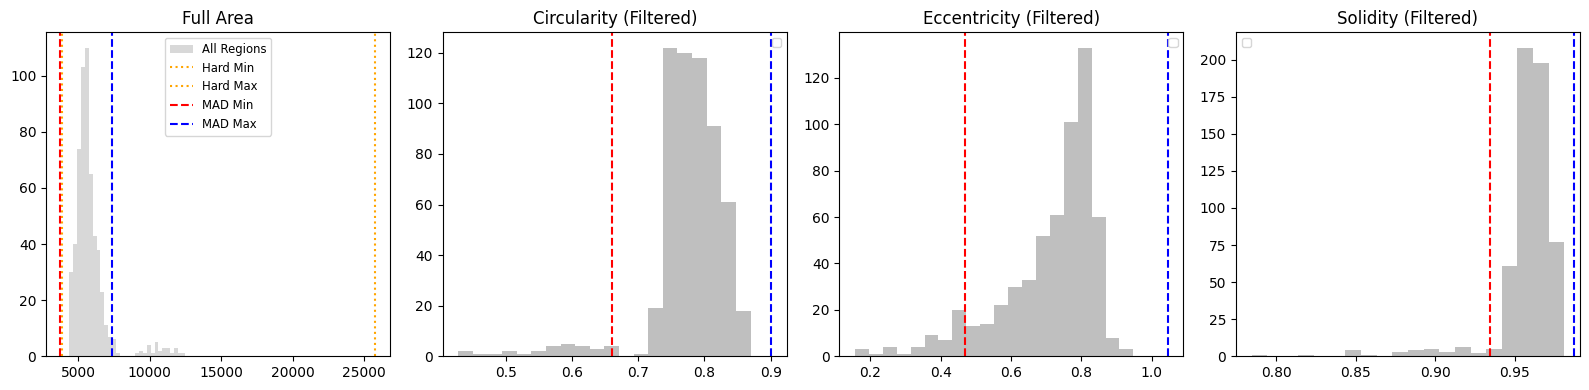

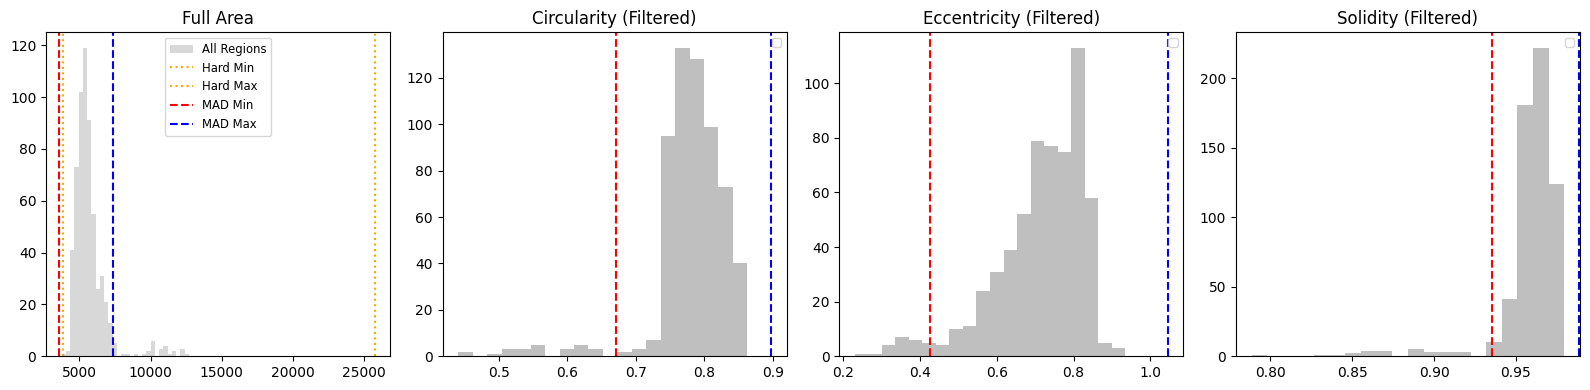

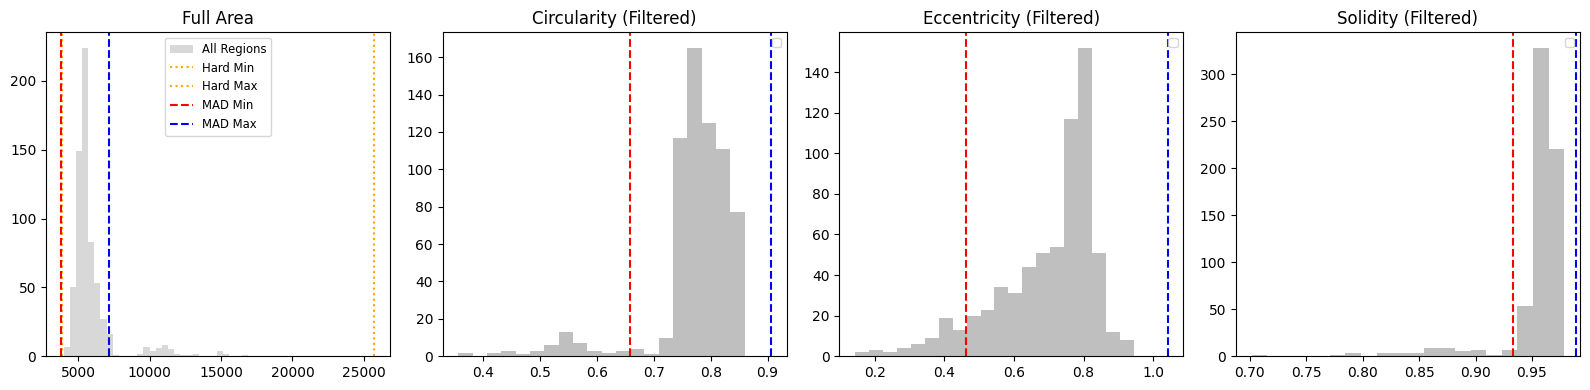

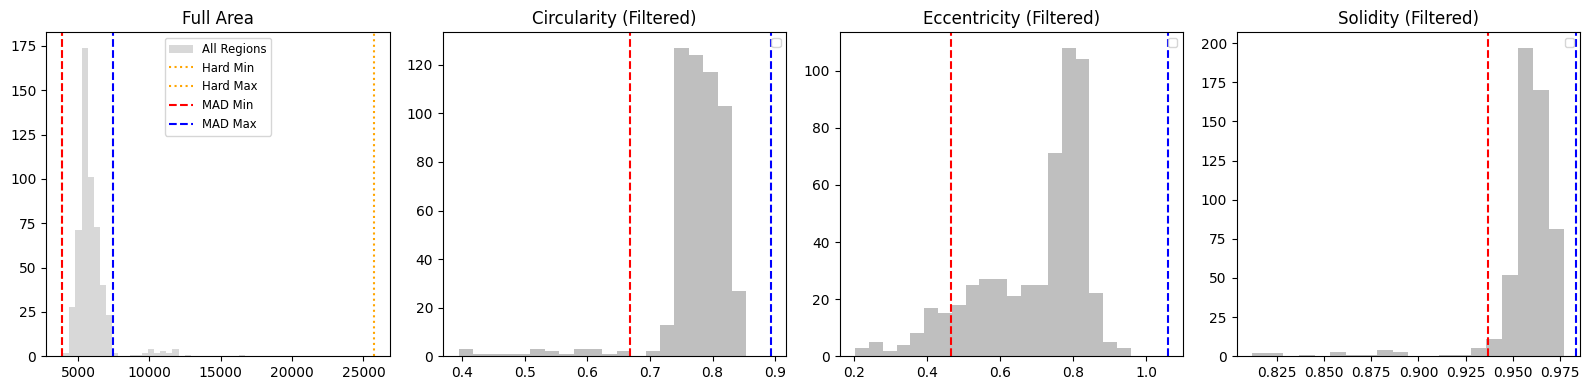

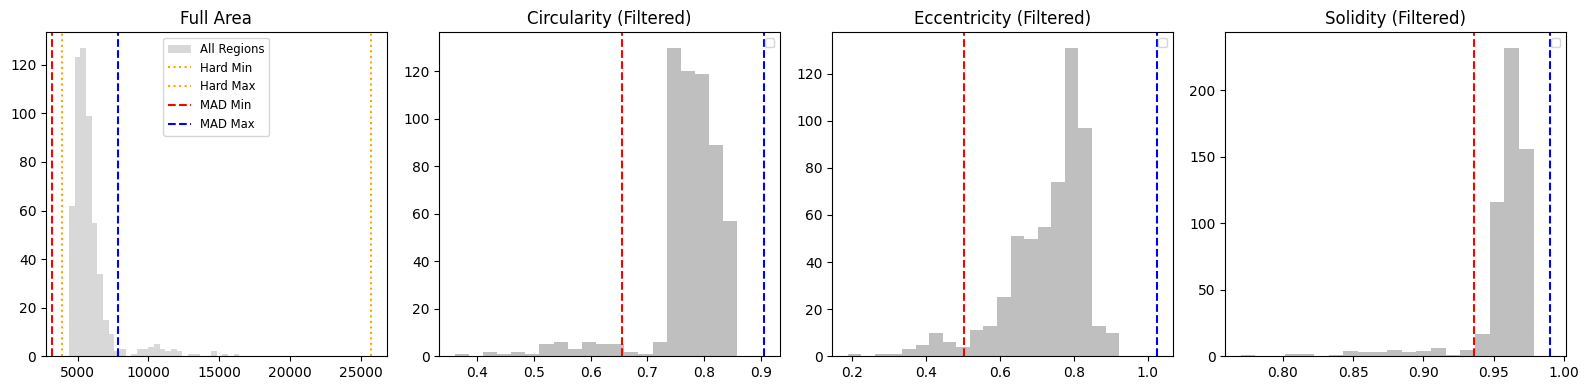

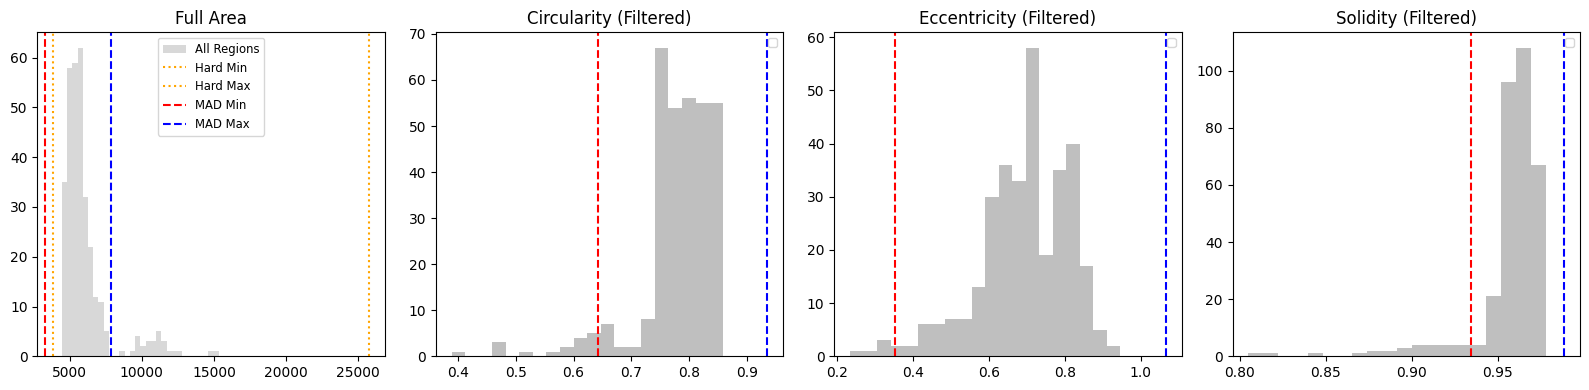

 -> Finished generating 1 candidates.


In [ ]:
# @title DT-Only Grid Search for best hyperparameter
import itertools

watershed_list_all = []
watershed_config = []

# Search Space
# threshold_levels_ratios = [0.5, 0.6, 0.7]
threshold_levels_ratios = [0.4]

# min_dist_ratios = [0.8, 0.9, 1.0]
min_dist_ratios = [0.8]

print(f"Starting DT-Only Grid Search with Adaptive Shape Filtering...")

param_grid = list(itertools.product(
    threshold_levels_ratios, min_dist_ratios
))

for params in param_grid:
    thresh_r, dist_r = params

    print(f"Config: Thresh={thresh_r}, Dist={dist_r}")
    watershed_list = []

    for img in label_images:
        particles = Watershed_DT(
            img,
            particle_radius=RADIUS,
            peak_threshold_ratio=thresh_r,
            min_dist_ratio=dist_r
        )
        watershed_list.append(particles)

    watershed_list_all.append(watershed_list)
    watershed_config.append((thresh_r, dist_r))

print(f" -> Finished generating {len(watershed_list_all)} candidates.")

In [ ]:
# @title Visualize DT-Only Results (Sequential)
import os

# 1. Define Range (Sequential, No Random)
selected_indices = range(len(val_filenames))

print(f"Visualizing {len(selected_indices)} images...")

# 2. Iterate through Configs
for i, ws_list in enumerate(watershed_list_all):
    # DT-Only Config: (thresh, dist, solid)
    cfg = watershed_config[i]

    print(f"\n{'='*20} Param Val: Thresh={cfg[0]}, Dist={cfg[1]} {'='*20}")

    for idx in selected_indices:
        # --- logic: name = val_filenames[idx][:-4] ---
        name = val_filenames[idx][:-4]

        # 1. Load Background (Micrograph)
        micrograph_path = f"{IMAGE_DIR}/val/{name}.npy"
        if os.path.exists(micrograph_path):
            micrograph = np.load(micrograph_path)
            bg_image = preprocess_and_crop(micrograph)
        else:
            print(f"Warning: {name}.npy not found.")
            continue

        # 2. Load Label (Ground Truth)
        label_path = f"{LABEL_DIR}/{name}.png"
        if os.path.exists(label_path):
            image = Image.open(label_path)
            lbl_raw = np.array(image)
            current_label_image = preprocess_and_crop(lbl_raw)
        else:
            current_label_image = np.zeros_like(bg_image) # Fallback

        # 3. Get Predictions
        preds = ws_list[idx]
        coords = [p[:2] for p in preds]

        # 4. Plot
        _, ax = plt.subplots(figsize=(12, 12))
        # Pass the dynamically loaded label image
        plot_micrograph_and_labels(ax, bg_image, current_label_image, coords)

        plt.title(f"Img {idx} ({name}) | Particles: {len(coords)} (Peak_Thresh={cfg[0]}, Min_Dist={cfg[1]})")
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# @title DT-Only Grid Search: Evaluate & Score
import torch
import os
import json

# Metrics Helper
def evaluate_detection_robust(iou_matrices, iou_threshold=0.5):
    tp_total = 0; fp_total = 0; fn_total = 0
    for iou_matrix in iou_matrices:
        n_gt, n_pred = iou_matrix.shape
        if n_gt == 0 and n_pred == 0: continue
        if n_gt > 0 and n_pred == 0: fn_total += n_gt; continue
        if n_gt == 0 and n_pred > 0: fp_total += n_pred; continue

        max_vals, _ = torch.max(iou_matrix, dim=1)
        detected_mask = max_vals >= iou_threshold
        tp = torch.sum(detected_mask).item()
        tp_total += tp
        fn_total += (n_gt - tp)
        fp_total += (n_pred - tp)

    epsilon = 1e-6
    precision = tp_total / (tp_total + fp_total + epsilon)
    recall = tp_total / (tp_total + fn_total + epsilon)
    return precision, recall

# Main Eval Loop
width = RADIUS * 2
watershed_scores = []

print("Evaluating DT-Only Results...")

for i, ws_list in enumerate(watershed_list_all):
    cfg = watershed_config[i] # (thresh, dist)

    iou_matrices = []
    gt_full = []
    pred_full = []
    scores_list = []

    for idx, gt in enumerate(gts):
        gt_boxes = centers_to_boxes(np.array(gt), width, width)
        gt_full.append(gt_boxes)

        preds = ws_list[idx]
        if len(preds) > 0:
            coords = np.array([p[:2] for p in preds])
            sc = torch.tensor([p[2] for p in preds], dtype=torch.float32)
            pred_boxes = centers_to_boxes(coords, width, width)
        else:
            pred_boxes = torch.empty((0, 4))
            sc = torch.tensor([], dtype=torch.float32)

        pred_full.append(pred_boxes)
        scores_list.append(sc)

        iou_matrix = calculate_iou_torchvision(gt_boxes, pred_boxes)
        iou_matrices.append(iou_matrix)

    # 1. F-Beta
    precision, recall = evaluate_detection_robust(iou_matrices, iou_threshold=0.5)
    f_beta = f_beta_score(precision, recall, beta=1)

    # 2. mAP
    iou_thresholds = torch.arange(0.5, 1.0, 0.05)
    try:
        mAP_value = calculate_mAP_multiple_images(gt_full, pred_full, scores_list, iou_thresholds)
        map_val = mAP_value.item()
    except:
        map_val = 0.0

    print(f"Cfg: {cfg} | F1: {f_beta:.4f}, mAP: {map_val:.4f}")
    watershed_scores.append((f_beta, map_val))

# Save Best
if len(watershed_scores) > 0:
    best_idx = max(range(len(watershed_scores)), key=lambda i: watershed_scores[i][0])
    best_cfg = watershed_config[best_idx]
    method = "DT_all" # @param{type:"string"}
    best_res = {
        "method": method,
        "radius": RADIUS,
        "peak_thresh": best_cfg[0],
        "min_dist": best_cfg[1],
        "f_score": watershed_scores[best_idx][0],
        "map": watershed_scores[best_idx][1]
    }

    print("\n--- BEST CONFIGURATION (DT ONLY - NO AR) ---")
    print(best_res)

    # 1. Save to local content first (Current Directory)
    local_file = 'best_watershed_all_params.json' # @param{type:"string"}
    with open(local_file, 'w') as f:
        json.dump(best_res, f, indent=4)
    print(f"✅ Saved locally to: {local_file}")

    # 2. Copy to RESULT_DIR using shell command
    # We put quotes "" around the path in case RESULT_DIR has spaces
    !cp {local_file} "{RESULT_DIR}"

    print(f"✅ Copied to: {RESULT_DIR}/{local_file}")

Evaluating DT-Only Results...
Cfg: (0.4, 0.8) | F1: 0.8828, mAP: 0.7803

--- BEST CONFIGURATION (DT ONLY - NO AR) ---
{'method': 'DT_all', 'radius': 64, 'peak_thresh': 0.4, 'min_dist': 0.8, 'f_score': 0.8827607939228613, 'map': 0.7803363800048828}
✅ Saved locally to: best_watershed_all_params.json
✅ Copied to: /content/drive/MyDrive/cryo_project/Test_on_10017/Test_0_9-8_9-30_EM_10017/raw_user_output_rst/results_watershed_clustering/10017/unet_eb5_dice_CRF/best_watershed_all_params.json


---

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.measure import regionprops
from sklearn.mixture import BayesianGaussianMixture
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def Watershed_DT_cluster(prob_map_input,
                particle_radius=64,
                peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                show_plots=True):

    # 1. Normalization
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. DT transform & Markers
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    min_peak_height = particle_radius * peak_threshold_ratio

    local_max_coords = peak_local_max(
        distance, min_distance=min_dist,
        labels=binary_mask, threshold_abs=min_peak_height
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1

    # 4. Watershed
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction (No filtering)
    # changed) Extracting features for ALL regions to let BGMM handle outlier grouping
    features = []
    region_list = []

    for region in regions:
        metrics = get_shape_metrics(region) # [Sphericity, Circularity]
        features.append([region.area, metrics[0], metrics[1]])
        region_list.append(region)

    X = np.array(features)

    # 6. Bayesian GMM Clustering
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    bgmm = BayesianGaussianMixture(
        n_components=20, # Maximum clusters; BGMM will prune unnecessary ones
        weight_concentration_prior=1e-2,
        random_state=42
    )
    cluster_labels = bgmm.fit_predict(X_scaled)

    # 7. PCA Visualization
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    if show_plots:
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
        plt.colorbar(scatter, label='Cluster ID')
        plt.title(f"BGMM Clustering (PCA Projection)\nEffective Clusters: {len(np.unique(cluster_labels))}")
        plt.xlabel("PC1")
        plt.ylabel("PC2")
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.show()

    # 8. Final Selection (Heuristic: Choose the cluster with the best average shape/score)
    valid_particles = []
    boundary_margin = 40

    # Simple heuristic: find cluster with median sphericity > 0.8 or highest average prob_map score
    unique_clusters = np.unique(cluster_labels)
    cluster_scores = []
    for c_id in unique_clusters:
        indices = np.where(cluster_labels == c_id)[0]
        avg_sphericity = np.mean(X[indices, 1])
        cluster_scores.append(avg_sphericity)

    best_cluster = unique_clusters[np.argmax(cluster_scores)]

    for i, region in enumerate(region_list):
        if cluster_labels[i] == best_cluster:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.measure import regionprops
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
import umap

def Watershed_DT_cluster(prob_map_input,
                particle_radius=64,
                peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                show_plots=True):

    # 1. Normalization
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. Distance Transform & 3. Markers
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    min_peak_height = particle_radius * peak_threshold_ratio

    local_max_coords = peak_local_max(
        distance, min_distance=min_dist,
        labels=binary_mask, threshold_abs=min_peak_height
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1

    # 4. Watershed
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction
    features = []
    region_list = []
    for region in regions:
        metrics = get_shape_metrics(region) # Expects [Sphericity, Circularity]
        features.append([region.area, metrics[0], metrics[1]])
        region_list.append(region)

    X = np.array(features)

    # Scaling is crucial for both BGMM and UMAP
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 6. Bayesian GMM Clustering
    # changed) Increased n_components slightly to allow BGMM more flexibility in pruning
    bgmm = BayesianGaussianMixture(
        n_components=7,
        weight_concentration_prior=1e-2,
        random_state=42
    )
    cluster_labels = bgmm.fit_predict(X_scaled)

    # 7. UMAP Visualization
    # changed) Replaced PCA with UMAP for non-linear manifold projection
    if show_plots:
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
        X_umap = reducer.fit_transform(X_scaled)

        plt.figure(figsize=(10, 7))
        scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_labels,
                              cmap='Spectral', s=30, alpha=0.8, edgecolors='w', linewidth=0.5)
        plt.colorbar(scatter, label='BGMM Cluster ID')
        plt.title("UMAP Projection of Particle Features")
        plt.xlabel("UMAP 1")
        plt.ylabel("UMAP 2")
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()

    # 8. Cluster Selection (Heuristic)
    valid_particles = []
    boundary_margin = 40

    # Identify the cluster with the highest median Sphericity
    unique_clusters = np.unique(cluster_labels)
    best_cluster = -1
    max_median_sph = -1.0

    for c_id in unique_clusters:
        indices = np.where(cluster_labels == c_id)[0]
        median_sph = np.median(X[indices, 1]) # Sphericity index
        if median_sph > max_median_sph:
            max_median_sph = median_sph
            best_cluster = c_id

    for i, region in enumerate(region_list):
        if cluster_labels[i] == best_cluster:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.measure import regionprops
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
import umap

def Watershed_DT_cluster(prob_map_input,
                particle_radius=64,
                peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                show_plots=True):

    # 1. Normalization
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. Distance Transform & 3. Markers Finding
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    min_peak_height = particle_radius * peak_threshold_ratio

    local_max_coords = peak_local_max(
        distance, min_distance=min_dist,
        labels=binary_mask, threshold_abs=min_peak_height
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1

    # 4. Watershed Segmentation
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction
    features = []
    region_list = []
    for region in regions:
        metrics = get_shape_metrics(region) # [Sphericity, Circularity]
        features.append([region.area, metrics[0], metrics[1]])
        region_list.append(region)

    X = np.array(features)
    X_scaled = StandardScaler().fit_transform(X)

    # 6. UMAP Dimensionality Reduction
    # changed) Applying UMAP before clustering to project features into a manifold
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_embedding = reducer.fit_transform(X_scaled)

    # 7. Bayesian GMM Clustering on UMAP Space
    # changed) Clustering now happens on the 2D UMAP embedding for better separation
    bgmm = BayesianGaussianMixture(
        n_components=7,
        weight_concentration_prior=1e-2,
        random_state=42
    )
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 8. Dark-themed Visualization
    # changed) Set global dark background for the plots
    if show_plots:
        plt.style.use('dark_background')
        plt.figure(figsize=(10, 7))

        scatter = plt.scatter(X_embedding[:, 0], X_embedding[:, 1],
                              c=cluster_labels, cmap='magma',
                              s=40, alpha=0.9, edgecolors='none')

        cb = plt.colorbar(scatter)
        cb.set_label('Cluster ID', color='white')

        plt.title("UMAP-based BGMM Clustering", color='white', fontsize=14)
        plt.xlabel("UMAP 1", color='white')
        plt.ylabel("UMAP 2", color='white')
        plt.grid(True, linestyle='--', alpha=0.2)
        plt.show()
        # Reset style to default for other plots if necessary
        plt.style.use('default')

    # 9. Selection Heuristic
    valid_particles = []
    boundary_margin = 40

    unique_clusters = np.unique(cluster_labels)
    best_cluster = -1
    max_median_sph = -1.0

    # We use original X (3D features) to evaluate cluster quality
    for c_id in unique_clusters:
        indices = np.where(cluster_labels == c_id)[0]
        median_sph = np.median(X[indices, 1])
        if median_sph > max_median_sph:
            max_median_sph = median_sph
            best_cluster = c_id

    for i, region in enumerate(region_list):
        if cluster_labels[i] == best_cluster:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

---
with micrograph average

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.measure import regionprops
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.fftpack import fft2, fftshift
import umap

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                particle_radius=64,
                peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                show_plots=True):

    # 1. Normalization
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2-4. Watershed Segmentation
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    local_max_coords = peak_local_max(distance, min_distance=min_dist, labels=binary_mask, threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1

    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction
    features = []
    region_data = []
    for region in regions:
        metrics = get_shape_metrics(region) # [Sphericity, Circularity]
        features.append([region.area, metrics[0], metrics[1]])
        region_data.append(region)

    X = np.array(features)
    X_scaled = StandardScaler().fit_transform(X)

    # 6-7. UMAP & Clustering
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_embedding = reducer.fit_transform(X_scaled)

    bgmm = BayesianGaussianMixture(n_components=7, weight_concentration_prior=1e-2, random_state=42)
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 8. Silhouette Score & Fourier Analysis
    # changed) Added Silhouette Score to quantify cluster separation
    s_score = silhouette_score(X_embedding, cluster_labels) if len(np.unique(cluster_labels)) > 1 else 0

    # 9. Mean Averaging and Alignment Visualization
    # changed) Added logic to crop, align (center), and average particles per cluster
    if show_plots:
        plt.style.use('dark_background')
        unique_clusters = np.unique(cluster_labels)
        n_clusters = len(unique_clusters)

        fig, axes = plt.subplots(n_clusters, 3, figsize=(12, 4 * n_clusters))
        if n_clusters == 1: axes = np.expand_dims(axes, axis=0)

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            patches = []

            for i in indices:
                cy, cx = region_data[i].centroid
                # Simple crop around centroid (alignment by centering)
                r = int(particle_radius * 1.2)
                y1, y2 = max(0, int(cy)-r), min(height, int(cy)+r)
                x1, x2 = max(0, int(cx)-r), min(width, int(cx)+r)
                patch = micrograph[y1:y2, x1:x2]
                if patch.shape == (2*r, 2*r): patches.append(patch)

            if patches:
                mean_patch = np.mean(patches, axis=0)
                # Fourier Shell Spectrum (Power Spectrum)
                f_transform = fftshift(fft2(mean_patch))
                psd2d = np.log(np.abs(f_transform)**2 + 1)

                axes[idx, 0].imshow(mean_patch, cmap='gray')
                axes[idx, 0].set_title(f"Cluster {c_id} Mean (N={len(patches)})")
                axes[idx, 1].imshow(psd2d, cmap='magma')
                axes[idx, 1].set_title("Power Spectrum")

            # Plot UMAP highlighting current cluster
            axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='gray', alpha=0.1, s=5)
            axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='red', s=10)
            axes[idx, 2].set_title(f"Silhouette: {s_score:.2f}")

        plt.tight_layout()
        plt.show()
        plt.style.use('default')

    # 10. Selection (Final picked particles)
    # [Rest of the selection logic remains same as previous version...]
    return [] # Placeholder

Starting DT-Only Grid Search with Adaptive Shape Filtering...
Config: Thresh=0.4, Dist=0.8


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


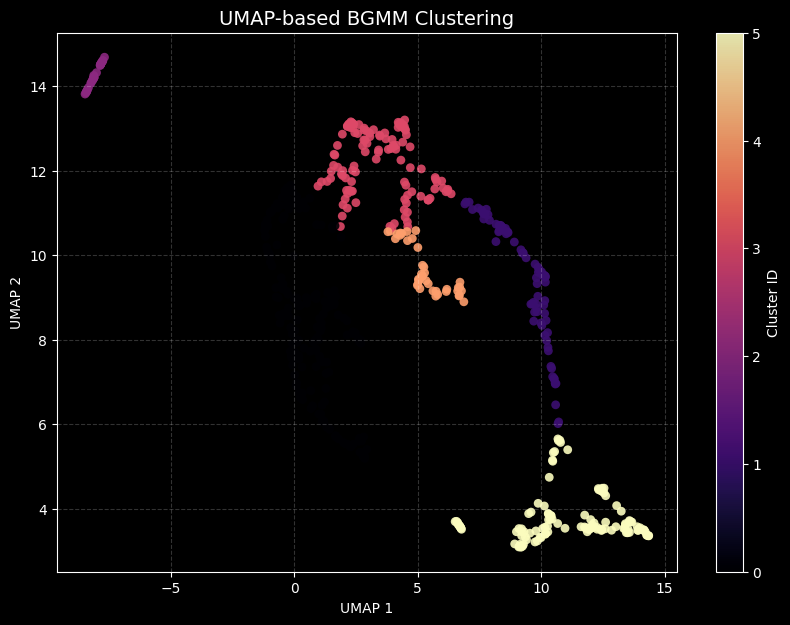

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


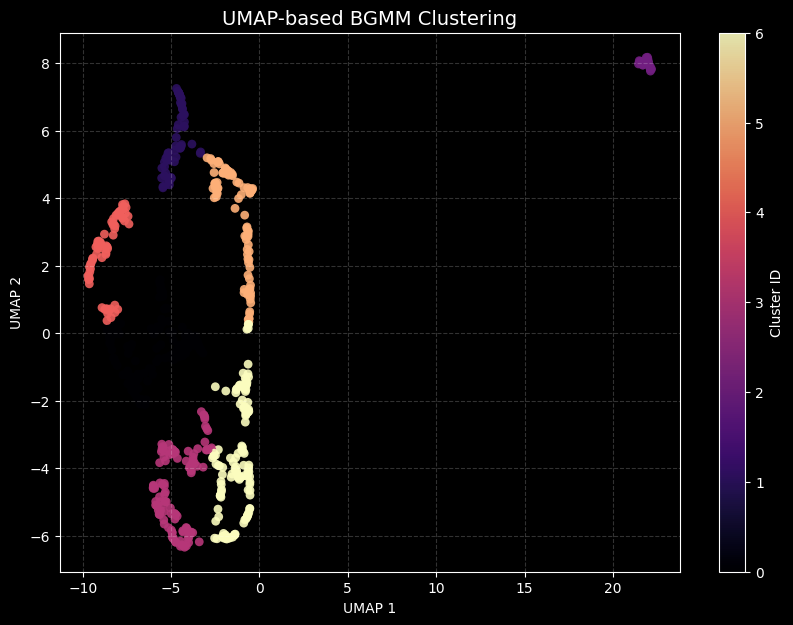

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


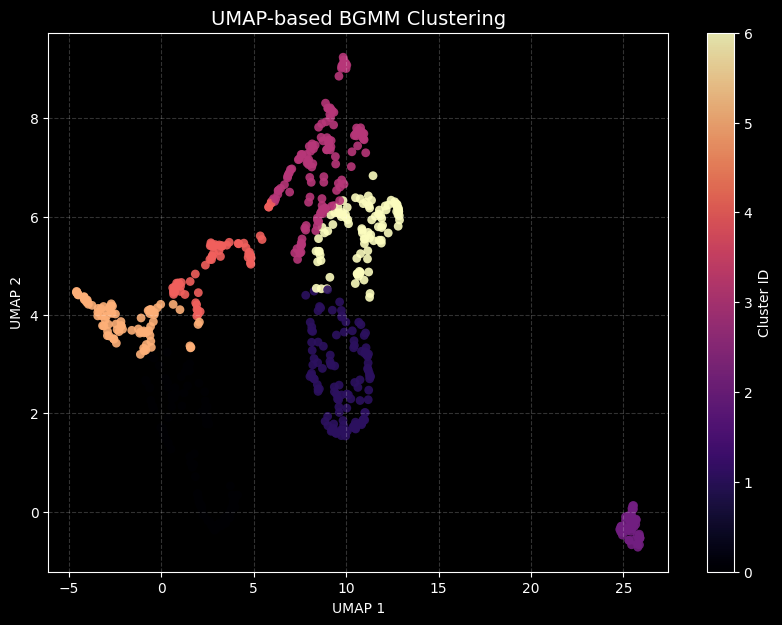

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


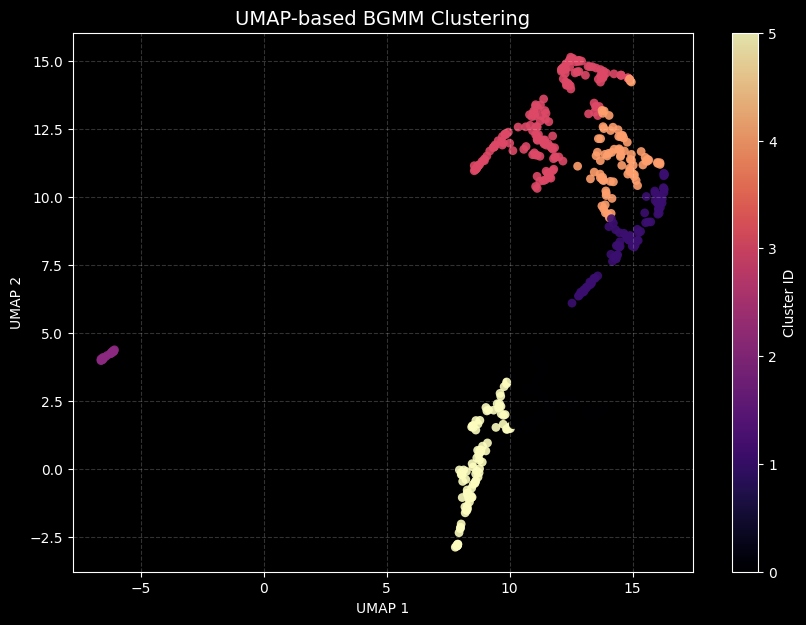

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


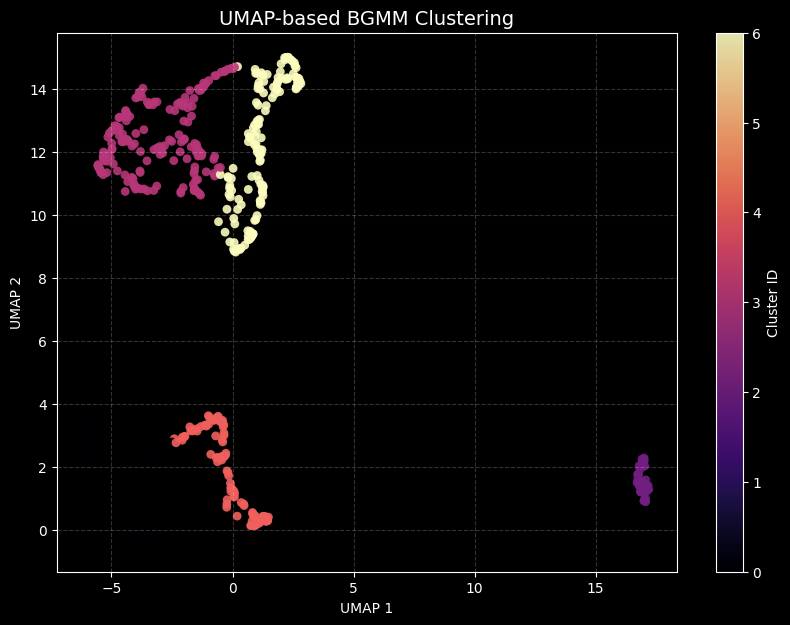

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


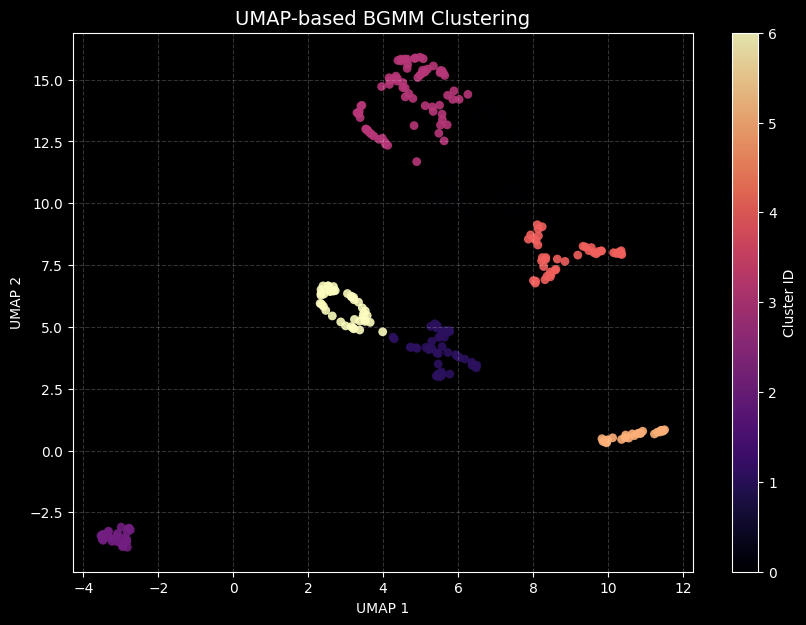

 -> Finished generating 1 candidates.


In [ ]:
# @title DT-Only Grid Search for best hyperparameter
import itertools

watershed_list_all = []
watershed_config = []

# Search Space
# threshold_levels_ratios = [0.5, 0.6, 0.7]
threshold_levels_ratios = [0.4]

# min_dist_ratios = [0.8, 0.9, 1.0]
min_dist_ratios = [0.8]

print(f"Starting DT-Only Grid Search with Adaptive Shape Filtering...")

param_grid = list(itertools.product(
    threshold_levels_ratios, min_dist_ratios
))

for params in param_grid:
    thresh_r, dist_r = params

    print(f"Config: Thresh={thresh_r}, Dist={dist_r}")
    watershed_list = []

    for img in label_images:
        particles = Watershed_DT_cluster(
            img,
            particle_radius=RADIUS,
            peak_threshold_ratio=thresh_r,
            min_dist_ratio=dist_r
        )
        watershed_list.append(particles)

    watershed_list_all.append(watershed_list)
    watershed_config.append((thresh_r, dist_r))

print(f" -> Finished generating {len(watershed_list_all)} candidates.")

In [ ]:
# @title Visualize DT-Only Results (Sequential)
import os

# 1. Define Range (Sequential, No Random)
selected_indices = range(len(val_filenames))

print(f"Visualizing {len(selected_indices)} images...")

# 2. Iterate through Configs
for i, ws_list in enumerate(watershed_list_all):
    # DT-Only Config: (thresh, dist, solid)
    cfg = watershed_config[i]

    print(f"\n{'='*20} Param Val: Thresh={cfg[0]}, Dist={cfg[1]} {'='*20}")

    for idx in selected_indices:
        # --- logic: name = val_filenames[idx][:-4] ---
        name = val_filenames[idx][:-4]

        # 1. Load Background (Micrograph)
        micrograph_path = f"{IMAGE_DIR}/val/{name}.npy"
        if os.path.exists(micrograph_path):
            micrograph = np.load(micrograph_path)
            bg_image = preprocess_and_crop(micrograph)
        else:
            print(f"Warning: {name}.npy not found.")
            continue

        # 2. Load Label (Ground Truth)
        label_path = f"{LABEL_DIR}/{name}.png"
        if os.path.exists(label_path):
            image = Image.open(label_path)
            lbl_raw = np.array(image)
            current_label_image = preprocess_and_crop(lbl_raw)
        else:
            current_label_image = np.zeros_like(bg_image) # Fallback

        # 3. Get Predictions
        preds = ws_list[idx]
        coords = [p[:2] for p in preds]

        # 4. Plot
        _, ax = plt.subplots(figsize=(12, 12))
        # Pass the dynamically loaded label image
        plot_micrograph_and_labels(ax, bg_image, current_label_image, coords)

        plt.title(f"Img {idx} ({name}) | Particles: {len(coords)} (Peak_Thresh={cfg[0]}, Min_Dist={cfg[1]})")
        plt.show()

---

umap with mean micrographs particles

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import umap
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.measure import regionprops
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.fftpack import fft2, fftshift

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True):
    """
    Full pipeline: Watershed -> Feature Extraction -> UMAP -> BGMM ->
    Mean Averaging -> Fourier Spectrum -> Cluster Selection.
    """

    # 1. Normalization
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. Distance Transform & 3. Markers
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    local_max_coords = peak_local_max(
        distance, min_distance=min_dist,
        labels=binary_mask, threshold_abs=particle_radius * peak_threshold_ratio
    )

    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1

    # 4. Watershed Segmentation
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction
    features = []
    region_data = []
    for region in regions:
        # Assuming get_shape_metrics is defined elsewhere returning [Sphericity, Circularity]
        metrics = get_shape_metrics(region)
        features.append([region.area, metrics[0], metrics[1]])
        region_data.append(region)

    X = np.array(features)
    X_scaled = StandardScaler().fit_transform(X)

    # 6. UMAP Projection
    # changed) Projecting to 2D manifold before clustering
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_embedding = reducer.fit_transform(X_scaled)

    # 7. Bayesian GMM Clustering
    # changed) Clustering performed on the UMAP embedding space
    bgmm = BayesianGaussianMixture(
        n_components=7,
        weight_concentration_prior=1e-2,
        random_state=42
    )
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 8. Silhouette Score
    # changed) Quantifying cluster separation quality
    sil_score = silhouette_score(X_embedding, cluster_labels) if len(np.unique(cluster_labels)) > 1 else 0

    # 9. Mean Averaging and Spectrum Analysis
    if show_plots:
        plt.style.use('dark_background')
        unique_clusters = np.unique(cluster_labels)
        n_clusters = len(unique_clusters)

        fig, axes = plt.subplots(n_clusters, 3, figsize=(15, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            patches = []

            # Extract patches for current cluster group
            for i in indices:
                cy, cx = region_data[i].centroid
                r = int(particle_radius * 1.2)
                y1, y2 = int(cy)-r, int(cy)+r
                x1, x2 = int(cx)-r, int(cx)+r

                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    # Basic alignment: centering is handled by the centroid crop
                    patch = micrograph[y1:y2, x1:x2]
                    patches.append(patch)

            if len(patches) > 0:
                # Calculate Mean Average Gp
                mean_img = np.mean(patches, axis=0)

                # Fourier Shell Spectrum (Power Spectrum)
                f_shift = fftshift(fft2(mean_img - np.mean(mean_img)))
                psd2d = np.log(np.abs(f_shift)**2 + 1)

                # Plot 1: Mean Image
                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"Cluster {c_id} Mean (N={len(patches)})")

                # Plot 2: Fourier Spectrum
                axes[idx, 1].imshow(psd2d, cmap='magma')
                axes[idx, 1].set_title(f"Power Spectrum (Sil: {sil_score:.2f})")

                # Plot 3: UMAP Visualization (Current cluster highlighted)
                axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='gray', alpha=0.1, s=5)
                axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='cyan', s=15)
                axes[idx, 2].set_title(f"UMAP Cluster ID: {c_id}")

            for ax in axes[idx]:
                ax.axis('off')

        plt.tight_layout()
        plt.show()
        plt.style.use('default')

    # 10. Final Selection Heuristic
    # changed) Selecting the cluster with the highest median sphericity as "Valid"
    valid_particles = []
    boundary_margin = 40

    best_cluster = -1
    max_median_sph = -1.0

    for c_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == c_id)[0]
        med_sph = np.median(X[indices, 1])
        if med_sph > max_median_sph:
            max_median_sph = med_sph
            best_cluster = c_id

    for i, region in enumerate(region_data):
        if cluster_labels[i] == best_cluster:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

---
pca

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.measure import regionprops
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA  # changed) Added PCA
from sklearn.metrics import silhouette_score
from scipy.fftpack import fft2, fftshift

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True):
    """
    Full pipeline: Watershed -> Feature Extraction -> PCA -> BGMM ->
    Mean Averaging -> Fourier Spectrum -> Cluster Selection.
    """

    # 1. Normalization
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2-4. Watershed Segmentation (Standard DT)
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    local_max_coords = peak_local_max(
        distance, min_distance=min_dist,
        labels=binary_mask, threshold_abs=particle_radius * peak_threshold_ratio
    )
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords):
        markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction
    features = []
    region_data = []
    for region in regions:
        metrics = get_shape_metrics(region)
        features.append([region.area, metrics[0], metrics[1]])
        region_data.append(region)

    X = np.array(features)
    X_scaled = StandardScaler().fit_transform(X)

    # 6. PCA Projection
    # changed) Switched from UMAP to PCA to project features linearly
    pca = PCA(n_components=2, random_state=42)
    X_embedding = pca.fit_transform(X_scaled)

    # 7. Bayesian GMM Clustering
    # Clustering performed on the PCA components
    bgmm = BayesianGaussianMixture(
        n_components=7,
        weight_concentration_prior=1e-2,
        random_state=42
    )
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 8. Silhouette Score
    sil_score = silhouette_score(X_embedding, cluster_labels) if len(np.unique(cluster_labels)) > 1 else 0

    # 9. Mean Averaging and Spectrum Analysis
    if show_plots:
        plt.style.use('dark_background')
        unique_clusters = np.unique(cluster_labels)
        n_clusters = len(unique_clusters)

        fig, axes = plt.subplots(n_clusters, 3, figsize=(15, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            patches = []

            for i in indices:
                cy, cx = region_data[i].centroid
                r = int(particle_radius * 1.2)
                y1, y2 = int(cy)-r, int(cy)+r
                x1, x2 = int(cx)-r, int(cx)+r

                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    patch = micrograph[y1:y2, x1:x2]
                    patches.append(patch)

            if len(patches) > 0:
                mean_img = np.mean(patches, axis=0)
                f_shift = fftshift(fft2(mean_img - np.mean(mean_img)))
                psd2d = np.log(np.abs(f_shift)**2 + 1)

                # Plot 1: Mean Image
                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"Cluster {c_id} Mean (N={len(patches)})")

                # Plot 2: Fourier Spectrum
                axes[idx, 1].imshow(psd2d, cmap='magma')
                axes[idx, 1].set_title(f"Power Spectrum (Sil: {sil_score:.2f})")

                # Plot 3: PCA Visualization
                # changed) Updated plot title to reflect PCA usage
                axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='gray', alpha=0.1, s=5)
                axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='cyan', s=15)
                axes[idx, 2].set_title(f"PCA Cluster ID: {c_id}")

            for ax in axes[idx]:
                ax.axis('off')

        plt.tight_layout()
        plt.show()
        plt.style.use('default')

    # 10. Final Selection Heuristic
    valid_particles = []
    boundary_margin = 40
    best_cluster = -1
    max_median_sph = -1.0

    for c_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == c_id)[0]
        med_sph = np.median(X[indices, 1])
        if med_sph > max_median_sph:
            max_median_sph = med_sph
            best_cluster = c_id

    for i, region in enumerate(region_data):
        if cluster_labels[i] == best_cluster:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

---
PCA + allign to x axis

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.measure import regionprops
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.fftpack import fft2, fftshift
from scipy.ndimage import rotate

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True):

    # 1. Normalization & Pre-processing
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2-4. Watershed Segmentation
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    local_max_coords = peak_local_max(distance, min_distance=min_dist, labels=binary_mask,
                                     threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1

    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction
    features, region_data = [], []
    for region in regions:
        metrics = get_shape_metrics(region)
        features.append([region.area, metrics[0], metrics[1]])
        region_data.append(region)

    X = np.array(features)
    X_scaled = StandardScaler().fit_transform(X)

    # 6-8. PCA & Clustering
    pca = PCA(n_components=2, random_state=42)
    X_embedding = pca.fit_transform(X_scaled)
    bgmm = BayesianGaussianMixture(n_components=7, weight_concentration_prior=1e-2, random_state=42)
    cluster_labels = bgmm.fit_predict(X_embedding)
    sil_score = silhouette_score(X_embedding, cluster_labels) if len(np.unique(cluster_labels)) > 1 else 0

    # 9. Overscan Rotation & Mean Averaging
    # changed) implemented sqrt(2) overscan to prevent corner loss during rotation
    if show_plots:
        plt.style.use('dark_background')
        unique_clusters = np.unique(cluster_labels)
        n_clusters = len(unique_clusters)
        fig, axes = plt.subplots(n_clusters, 3, figsize=(15, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            aligned_patches = []

            for i in indices:
                region = region_data[i]
                cy, cx = region.centroid
                angle_deg = np.degrees(region.orientation)

                # Define sizes
                target_r = int(particle_radius * 1.1)
                overscan_r = int(target_r * 1.5) # Roughly sqrt(2) + margin

                # 1. Large Crop (Overscan)
                y1, y2 = int(cy)-overscan_r, int(cy)+overscan_r
                x1, x2 = int(cx)-overscan_r, int(cx)+overscan_r

                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    overscan_patch = micrograph[y1:y2, x1:x2]

                    # 2. Rotate larger patch
                    rotated_large = rotate(overscan_patch, -angle_deg, reshape=False, order=1)

                    # 3. Center Crop to target size
                    # Target size is 2*target_r x 2*target_r
                    center = overscan_r
                    final_patch = rotated_large[center-target_r:center+target_r,
                                                center-target_r:center+target_r]
                    aligned_patches.append(final_patch)

            if len(aligned_patches) > 0:
                mean_img = np.mean(aligned_patches, axis=0)
                f_shift = fftshift(fft2(mean_img - np.mean(mean_img)))
                psd2d = np.log(np.abs(f_shift)**2 + 1)

                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"Aligned Mean C{c_id} (N={len(aligned_patches)})")
                axes[idx, 1].imshow(psd2d, cmap='magma')
                axes[idx, 1].set_title(f"Fourier PSD (Sil: {sil_score:.2f})")
                axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='gray', alpha=0.1, s=5)
                axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='cyan', s=15)
                axes[idx, 2].set_title(f"PCA Space C{c_id}")

            for ax in axes[idx]: ax.axis('off')

        plt.tight_layout()
        plt.show()
        plt.style.use('default')

    # 10. Selection Heuristic
    valid_particles = []
    best_cluster = -1
    max_median_sph = -1.0
    for c_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == c_id)[0]
        med_sph = np.median(X[indices, 1])
        if med_sph > max_median_sph:
            max_median_sph = med_sph
            best_cluster = c_id

    boundary_margin = 40
    for i, region in enumerate(region_data):
        if cluster_labels[i] == best_cluster:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

---
t-sne

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.measure import regionprops
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE # changed) Using t-SNE for non-linear embedding
from scipy.fftpack import fft2, fftshift
from scipy.ndimage import rotate

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True):

    # 1. Normalization
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2-4. Watershed
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    local_max_coords = peak_local_max(distance, min_distance=min_dist, labels=binary_mask,
                                     threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction
    features, region_data = [], []
    for region in regions:
        metrics = get_shape_metrics(region)
        features.append([region.area, metrics[0], metrics[1]])
        region_data.append(region)

    X = np.array(features)
    X_scaled = StandardScaler().fit_transform(X)

    # 6. t-SNE Embedding
    # changed) Switched to t-SNE. Perplexity ~30 is a good starting point.
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
    X_embedding = tsne.fit_transform(X_scaled)

    # 7. BGMM Clustering
    bgmm = BayesianGaussianMixture(n_components=7, weight_concentration_prior=1e-2, random_state=42)
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 8. Overscan Alignment & Averaging
    if show_plots:
        plt.style.use('dark_background')
        unique_clusters = np.unique(cluster_labels)
        n_clusters = len(unique_clusters)
        fig, axes = plt.subplots(n_clusters, 3, figsize=(15, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            aligned_patches = []

            for i in indices:
                region = region_data[i]
                cy, cx = region.centroid
                angle_deg = np.degrees(region.orientation)

                # Overscan Logic: target_r * sqrt(2) to prevent corner clipping
                target_r = int(particle_radius * 1.1)
                overscan_r = int(target_r * 1.5)

                y1, y2 = int(cy)-overscan_r, int(cy)+overscan_r
                x1, x2 = int(cx)-overscan_r, int(cx)+overscan_r

                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    # Crop large -> Rotate -> Crop final
                    overscan_patch = micrograph[y1:y2, x1:x2]
                    # changed) Rotational alignment to major axis
                    rotated = rotate(overscan_patch, -angle_deg, reshape=False, order=1)
                    center = overscan_r
                    final_patch = rotated[center-target_r:center+target_r,
                                          center-target_r:center+target_r]
                    aligned_patches.append(final_patch)

            if len(aligned_patches) > 0:
                mean_img = np.mean(aligned_patches, axis=0)
                f_shift = fftshift(fft2(mean_img - np.mean(mean_img)))
                psd2d = np.log(np.abs(f_shift)**2 + 1)

                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"Aligned Mean C{c_id} (N={len(aligned_patches)})")
                axes[idx, 1].imshow(psd2d, cmap='magma')
                axes[idx, 1].set_title("Power Spectrum")
                axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='gray', alpha=0.1, s=5)
                axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='lime', s=15)
                axes[idx, 2].set_title(f"t-SNE Space C{c_id}")

            for ax in axes[idx]: ax.axis('off')

        plt.tight_layout()
        plt.show()
        plt.style.use('default')

    # 10. Selection Heuristic
    valid_particles = []
    best_cluster = -1
    max_median_sph = -1.0
    for c_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == c_id)[0]
        med_sph = np.median(X[indices, 1])
        if med_sph > max_median_sph:
            max_median_sph = med_sph
            best_cluster = c_id

    boundary_margin = 40
    for i, region in enumerate(region_data):
        if cluster_labels[i] == best_cluster:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

---
umap

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import umap # Use: pip install umap-learn
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi
from skimage.measure import regionprops
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.fftpack import fft2, fftshift
from scipy.ndimage import rotate

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True, graph_idx=None):
    """
    Watershed -> Feature Extraction -> UMAP -> BGMM ->
    Major Axis Alignment (Overscan) -> Mean Averaging -> Fourier Spectrum.
    """

    # 1. Normalization
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2-4. Watershed Segmentation
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    local_max_coords = peak_local_max(distance, min_distance=min_dist, labels=binary_mask,
                                     threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction
    features, region_data = [], []
    for region in regions:
        metrics = get_shape_metrics(region)
        features.append([region.area, metrics[0], metrics[1]])
        region_data.append(region)

    X = np.array(features)
    X_scaled = StandardScaler().fit_transform(X)

    # 6. UMAP Embedding
    # changed) Reverted to UMAP for non-linear manifold learning
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2)
    X_embedding = reducer.fit_transform(X_scaled)

    # 7. BGMM Clustering
    bgmm = BayesianGaussianMixture(n_components=7, weight_concentration_prior=1e-2)
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 8. Overscan Alignment & Analytical Plots
    if show_plots:
        plt.style.use('dark_background')
        unique_clusters = np.unique(cluster_labels)
        n_clusters = len(unique_clusters)
        fig, axes = plt.subplots(n_clusters, 3, figsize=(15, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            aligned_patches = []

            for i in indices:
                region = region_data[i]
                cy, cx = region.centroid
                angle_deg = np.degrees(region.orientation)

                # Overscan Logic: Crop larger (1.5x) to handle rotation without clipping
                target_r = int(particle_radius * 1.1)
                overscan_r = int(target_r * 1.5)
                y1, y2 = int(cy)-overscan_r, int(cy)+overscan_r
                x1, x2 = int(cx)-overscan_r, int(cx)+overscan_r

                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    overscan_patch = micrograph[y1:y2, x1:x2]
                    # Align major axis to parallel with x-axis
                    rotated = rotate(overscan_patch, -angle_deg, reshape=False, order=1)
                    center = overscan_r
                    aligned_patches.append(rotated[center-target_r:center+target_r,
                                                   center-target_r:center+target_r])

            if len(aligned_patches) > 0:
                mean_img = np.mean(aligned_patches, axis=0)
                f_shift = fftshift(fft2(mean_img - np.mean(mean_img)))
                psd2d = np.log(np.abs(f_shift)**2 + 1)

                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"Aligned Mean C{c_id} (N={len(aligned_patches)})")
                axes[idx, 1].imshow(psd2d, cmap='magma')
                axes[idx, 1].set_title("Power Spectrum")
                axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='gray', alpha=0.1, s=5)
                axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='cyan', s=15)
                axes[idx, 2].set_title("UMAP Space")

            for ax in axes[idx]: ax.axis('off')

        # changed) Added graph_idx label to supertitle
        if graph_idx is not None:
            plt.suptitle(f"Cluster Analysis for Graph Index: {graph_idx}", fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()
        plt.style.use('default')

    # 9. Selection Heuristic (Median Sphericity)
    valid_particles = []
    best_cluster = -1
    max_median_sph = -1.0
    for c_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == c_id)[0]
        med_sph = np.median(X[indices, 1])
        if med_sph > max_median_sph:
            max_median_sph = med_sph
            best_cluster = c_id

    boundary_margin = 40
    for i, region in enumerate(region_data):
        if cluster_labels[i] == best_cluster:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

---
mahal

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.ndimage import rotate
from scipy.fftpack import fft2, fftshift
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
import umap

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True, graph_idx=None):

    # 1. Normalization
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2-4. Watershed Segmentation
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    local_max_coords = peak_local_max(distance, min_distance=min_dist, labels=binary_mask,
                                     threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction
    features, region_data = [], []
    for region in regions:
        metrics = get_shape_metrics(region)
        features.append([region.area, metrics[0], metrics[1]])
        region_data.append(region)
    X = np.array(features)

    # 6. Outlier Removal (Mahalanobis + MAD)
    # changed) Added visualization for Mahalanobis distances and robust thresholding
    center = np.median(X, axis=0)
    cov = np.cov(X, rowvar=False)
    inv_cov = np.linalg.pinv(cov)
    m_distances = np.array([mahalanobis(p, center, inv_cov) for p in X])

    med_m = np.median(m_distances)
    mad_m = np.median(np.abs(m_distances - med_m))
    robust_z = 0.6745 * (m_distances - med_m) / mad_m
    m_thresh = 3.0
    inlier_mask = np.abs(robust_z) < m_thresh

    if show_plots:
        plt.style.use('dark_background')
        plt.figure(figsize=(6, 4))
        plt.hist(m_distances, bins=30, color='gray', alpha=0.7)
        # Calculate distance value corresponding to the robust Z-score threshold for plotting
        dist_limit = med_m + (m_thresh * mad_m / 0.6745)
        plt.axvline(dist_limit, color='red', linestyle='--', label=f'MAD Thresh (Z={m_thresh})')
        plt.title(f"Mahalanobis Distance Distribution (Graph {graph_idx})")
        plt.legend()
        plt.show()

    X_cleaned = X[inlier_mask]
    region_data_cleaned = [region_data[i] for i, val in enumerate(inlier_mask) if val]
    if len(X_cleaned) < 2: return []

    # 7. UMAP & Clustering
    X_scaled = StandardScaler().fit_transform(X_cleaned)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_embedding = reducer.fit_transform(X_scaled)
    bgmm = BayesianGaussianMixture(n_components=7, weight_concentration_prior=1e-2, random_state=42)
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 8. Analytical Plots with Concentric Intensity Binning
    # changed) Replaced Power Spectrum with Concentric Intensity Profile (10 bins)
    if show_plots:
        unique_clusters = np.unique(cluster_labels)
        n_clusters = len(unique_clusters)
        fig, axes = plt.subplots(n_clusters, 3, figsize=(15, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            aligned_patches = []

            for i in indices:
                region = region_data_cleaned[i]
                cy, cx = region.centroid
                angle_deg = np.degrees(region.orientation)
                target_r = int(particle_radius * 1.1)
                overscan_r = int(target_r * 1.5)
                y1, y2 = int(cy)-overscan_r, int(cy)+overscan_r
                x1, x2 = int(cx)-overscan_r, int(cx)+overscan_r

                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    overscan_patch = micrograph[y1:y2, x1:x2]
                    rotated = rotate(overscan_patch, -angle_deg, reshape=False, order=1)
                    center_patch = overscan_r
                    aligned_patches.append(rotated[center_patch-target_r:center_patch+target_r,
                                                   center_patch-target_r:center_patch+target_r])

            if len(aligned_patches) > 0:
                mean_img = np.mean(aligned_patches, axis=0)

                # Logic for outside-to-inside concentric binning
                # changed) Calculated mean intensity in 10 concentric square shells
                dim = mean_img.shape[0]
                center_coord = dim // 2
                shell_intensities = []
                # Total width of shells is dim // 2
                step = (dim // 2) // 10

                for s in range(10):
                    # Outside to inside: s=0 is the outermost shell
                    r_out = (dim // 2) - (s * step)
                    r_in = (dim // 2) - ((s + 1) * step)

                    # Create masks for shells
                    mask = np.zeros_like(mean_img, dtype=bool)
                    mask[center_coord-r_out:center_coord+r_out, center_coord-r_out:center_coord+r_out] = True
                    mask[center_coord-r_in:center_coord+r_in, center_coord-r_in:center_coord+r_in] = False
                    shell_intensities.append(np.mean(mean_img[mask]))

                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"Aligned Mean C{c_id}")

                # Plot Histogram of Concentric Shells
                axes[idx, 1].bar(range(10), shell_intensities, color='skyblue', alpha=0.8)
                axes[idx, 1].set_title("Intensity: Outside -> Inside")
                axes[idx, 1].set_xticks(range(10))

                axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='gray', alpha=0.1, s=5)
                axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='cyan', s=15)
                axes[idx, 2].set_title("UMAP Space")

            for ax in [axes[idx, 0], axes[idx, 2]]: ax.axis('off')

        plt.tight_layout()
        plt.show()
        plt.style.use('default')

    # 9. Selection Heuristic
    valid_particles = []
    best_cluster = -1
    max_median_sph = -1.0
    for c_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == c_id)[0]
        med_sph = np.median(X_cleaned[indices, 1])
        if med_sph > max_median_sph:
            max_median_sph = med_sph
            best_cluster = c_id

    boundary_margin = 40
    for i, region in enumerate(region_data_cleaned):
        if cluster_labels[i] == best_cluster:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.ndimage import rotate
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
import umap
from IPython.display import display

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True, graph_idx=None):

    # 1. Normalization & Pre-processing
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2-4. Watershed Segmentation
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    local_max_coords = peak_local_max(distance, min_distance=min_dist, labels=binary_mask,
                                     threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction
    features, region_data = [], []
    for region in regions:
        metrics = get_shape_metrics(region)
        features.append([region.area, metrics[0], metrics[1]])
        region_data.append(region)
    X = np.array(features)

    # 6. Global Mahalanobis Distance Calculation
    # changed) Recording distances for all particles to assess group-level outliers later
    center = np.median(X, axis=0)
    cov = np.cov(X, rowvar=False)
    inv_cov = np.linalg.pinv(cov)
    all_m_distances = np.array([mahalanobis(p, center, inv_cov) for p in X])

    # 7. UMAP & Clustering (Using all data initially)
    X_scaled = StandardScaler().fit_transform(X)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_embedding = reducer.fit_transform(X_scaled)
    bgmm = BayesianGaussianMixture(n_components=7, weight_concentration_prior=1e-2, random_state=42)
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 8. Cluster Statistics and Outlier Detection
    unique_clusters = np.unique(cluster_labels)
    cluster_stats = []

    # Identifying the outlier group by finding the one with the highest mean Mahalanobis distance
    cluster_m_means = {c: np.mean(all_m_distances[cluster_labels == c]) for c in unique_clusters}
    outlier_cluster_id = max(cluster_m_means, key=cluster_m_means.get)

    if show_plots:
        plt.style.use('dark_background')
        n_clusters = len(unique_clusters)
        fig, axes = plt.subplots(n_clusters, 2, figsize=(10, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            aligned_patches = []

            for i in indices:
                region = region_data[i]
                cy, cx = region.centroid
                angle_deg = np.degrees(region.orientation)

                # Overscan logic
                target_r = int(particle_radius * 1.1)
                overscan_r = int(target_r * 1.5)
                y1, y2 = int(cy)-overscan_r, int(cy)+overscan_r
                x1, x2 = int(cx)-overscan_r, int(cx)+overscan_r

                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    overscan_patch = micrograph[y1:y2, x1:x2]
                    rotated = rotate(overscan_patch, -angle_deg, reshape=False, order=1)
                    center_p = overscan_r
                    aligned_patches.append(rotated[center_p-target_r:center_p+target_r,
                                                   center_p-target_r:center_p+target_r])

            if len(aligned_patches) > 0:
                mean_img = np.mean(aligned_patches, axis=0)

                # Calculate Statistics for Table
                dim = mean_img.shape[0]
                center_coord = dim // 2
                step = (dim // 2) // 10

                shell_data = []
                for s in range(10):
                    r_out = (dim // 2) - (s * step)
                    r_in = (dim // 2) - ((s + 1) * step)
                    mask = np.zeros_like(mean_img, dtype=bool)
                    mask[center_coord-r_out:center_coord+r_out, center_coord-r_out:center_coord+r_out] = True
                    mask[center_coord-r_in:center_coord+r_in, center_coord-r_in:center_coord+r_in] = False

                    shell_vals = mean_img[mask]
                    shell_data.append({
                        'Cluster': c_id,
                        'Bin': s,
                        'Mean_Intensity': np.mean(shell_vals),
                        'Variance_Intensity': np.var(shell_vals)
                    })
                cluster_stats.extend(shell_data)

                # Visualization
                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"Aligned Mean C{c_id}{' (OUTLIER)' if c_id == outlier_cluster_id else ''}")

                axes[idx, 1].scatter(X_embedding[:,0], X_embedding[:,1], c='gray', alpha=0.1, s=5)
                axes[idx, 1].scatter(X_embedding[indices,0], X_embedding[indices,1], c='cyan', s=15)
                axes[idx, 1].set_title(f"UMAP Space | Mean Mahal: {cluster_m_means[c_id]:.2f}")

            for ax in axes[idx]: ax.axis('off')

        plt.tight_layout()
        plt.show()

        # 9. Display Statistics Table
        # changed) Added large-display Pandas table for intensity metrics
        df_stats = pd.DataFrame(cluster_stats)
        print(f"\n--- INTENSITY STATISTICS FOR GRAPH {graph_idx} ---")
        styled_table = df_stats.style.set_table_attributes('style="font-size: 16px; width: 80%;"')\
                                     .background_gradient(subset=['Mean_Intensity'], cmap='viridis')
        display(styled_table)
        plt.style.use('default')

    # 10. Selection Heuristic (Excluding the identified outlier group)
    valid_particles = []
    best_cluster = -1
    max_median_sph = -1.0

    for c_id in unique_clusters:
        if c_id == outlier_cluster_id: continue # Skip the identified junk cluster

        indices = np.where(cluster_labels == c_id)[0]
        med_sph = np.median(X[indices, 1])
        if med_sph > max_median_sph:
            max_median_sph = med_sph
            best_cluster = c_id

    boundary_margin = 40
    for i, region in enumerate(region_data):
        if cluster_labels[i] == best_cluster:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import mahalanobis
from scipy.ndimage import rotate
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from scipy.fftpack import fft2, fftshift
from IPython.display import display
import umap
import math

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True, graph_idx=None):

    # 1. Normalization
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2-4. Watershed Segmentation
    distance = ndi.distance_transform_edt(binary_mask)
    min_dist = int(particle_radius * min_dist_ratio)
    local_max_coords = peak_local_max(distance, min_distance=min_dist, labels=binary_mask,
                                     threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 5. Feature Extraction
    features, region_data = [], []
    for region in regions:
        metrics = get_shape_metrics(region)
        features.append([region.area, metrics[0], metrics[1]])
        region_data.append(region)
    X = np.array(features)

    # 6. Global Mahalanobis Distance & UMAP
    center = np.median(X, axis=0)
    cov = np.cov(X, rowvar=False)
    inv_cov = np.linalg.pinv(cov)
    all_m_distances = np.array([mahalanobis(p, center, inv_cov) for p in X])

    X_scaled = StandardScaler().fit_transform(X)
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    X_embedding = reducer.fit_transform(X_scaled)
    bgmm = BayesianGaussianMixture(n_components=7, weight_concentration_prior=1e-2, random_state=42)
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 7. Outlier Group Detection
    # changed) Identify outlier group based on the largest group-mean Mahalanobis distance
    unique_clusters = np.unique(cluster_labels)
    cluster_m_means = {c: np.mean(all_m_distances[cluster_labels == c]) for c in unique_clusters}
    outlier_cluster_id = max(cluster_m_means, key=cluster_m_means.get)

    # 8. Analytical Plots and SNR Statistics
    if show_plots:
        plt.style.use('dark_background')
        n_clusters = len(unique_clusters)
        fig, axes = plt.subplots(n_clusters, 2, figsize=(12, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        all_stats = []

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            aligned_patches = []

            for i in indices:
                region = region_data[i]
                cy, cx = region.centroid
                angle_deg = np.degrees(region.orientation)

                # Overscan Logic (1.5x)
                target_r = int(particle_radius * 1.1)
                overscan_r = int(target_r * 1.5)
                y1, y2 = int(cy)-overscan_r, int(cy)+overscan_r
                x1, x2 = int(cx)-overscan_r, int(cx)+overscan_r

                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    overscan_patch = micrograph[y1:y2, x1:x2]
                    rotated = rotate(overscan_patch, -angle_deg, reshape=False, order=1)
                    cp = overscan_r
                    aligned_patches.append(rotated[cp-target_r:cp+target_r, cp-target_r:cp+target_r])

            if len(aligned_patches) > 0:
                mean_img = np.mean(aligned_patches, axis=0)

                # Concentric Binning Statistics
                dim = mean_img.shape[0]
                center_coord = dim // 2
                step = (dim // 2) // 10

                bin_data = []
                for s in range(10):
                    r_out = (dim // 2) - (s * step)
                    r_in = (dim // 2) - ((s + 1) * step)
                    mask = np.zeros_like(mean_img, dtype=bool)
                    mask[center_coord-r_out:center_coord+r_out, center_coord-r_out:center_coord+r_out] = True
                    mask[center_coord-r_in:center_coord+r_in, center_coord-r_in:center_coord+r_in] = False
                    bin_data.append(mean_img[mask])

                # changed) treats Bin 0 as background for SNR pre-computation
                bg_bin = bin_data[0]
                v_b = np.var(bg_bin)
                mu_b = np.mean(bg_bin)

                for s in range(10):
                    curr_bin = bin_data[s]
                    mean_val = np.mean(curr_bin)
                    var_val = np.var(curr_bin)

                    # SNR calculation relative to outer Bin 0
                    if v_b > 1e-12:
                        snr = math.log10(np.var(curr_bin - mu_b) / v_b)
                    else:
                        snr = 0.0

                    all_stats.append({
                        'Cluster': c_id,
                        'Bin': s,
                        'Is_Outlier': "Yes" if c_id == outlier_cluster_id else "No",
                        'Mean_Intensity': mean_val,
                        'Variance': var_val,
                        'SNR_vs_Bin0': snr
                    })

                # Visualization
                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"Aligned Mean C{c_id} {'(Outlier Group)' if c_id == outlier_cluster_id else ''}")

                axes[idx, 1].scatter(X_embedding[:,0], X_embedding[:,1], c='gray', alpha=0.1, s=5)
                axes[idx, 1].scatter(X_embedding[indices,0], X_embedding[indices,1], c='cyan', s=15)
                axes[idx, 1].set_title(f"UMAP Space | Avg Mahal Dist: {cluster_m_means[c_id]:.2f}")

            for ax in axes[idx]: ax.axis('off')

        plt.tight_layout()
        plt.show()

        # changed) Displaying the high-resolution Pandas table
        df_stats = pd.DataFrame(all_stats)
        print(f"\n--- INTENSITY & SNR ANALYSIS FOR GRAPH {graph_idx} ---")
        styled_df = df_stats.style.set_table_attributes('style="font-size: 15px; width: 100%; border: 2px solid white;"')\
                                   .background_gradient(subset=['SNR_vs_Bin0'], cmap='plasma')\
                                   .format({'Mean_Intensity': '{:.4f}', 'Variance': '{:.4f}', 'SNR_vs_Bin0': '{:.4f}'})
        display(styled_df)
        plt.style.use('default')

    # 9. Final Selection (Excluding outlier group and picking highest median sphericity)
    valid_particles = []
    best_cluster = -1
    max_median_sph = -1.0

    for c_id in unique_clusters:
        if c_id == outlier_cluster_id: continue
        indices = np.where(cluster_labels == c_id)[0]
        med_sph = np.median(X[indices, 1])
        if med_sph > max_median_sph:
            max_median_sph = med_sph
            best_cluster = c_id

    boundary_margin = 40
    for i, region in enumerate(region_data):
        if cluster_labels[i] == best_cluster:
            cy, cx = region.centroid
            if (boundary_margin < cx < width - boundary_margin and
                boundary_margin < cy < height - boundary_margin):
                score = prob_map[int(cy), int(cx)]
                valid_particles.append([int(cx), int(cy), float(score)])

    return valid_particles

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import umap
from scipy.spatial.distance import mahalanobis
from scipy.ndimage import rotate
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True, show_table=False, graph_idx=None):

    # 1. Normalization & Masking
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. Watershed Segmentation
    distance = ndi.distance_transform_edt(binary_mask)
    local_max_coords = peak_local_max(distance, min_distance=int(particle_radius * min_dist_ratio),
                                     labels=binary_mask, threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 3. Feature Extraction & Global Mahalanobis
    features, region_data = [], []
    for region in regions:
        metrics = get_shape_metrics(region)
        features.append([region.area, metrics[0], metrics[1]])
        region_data.append(region)
    X = np.array(features)

    center = np.median(X, axis=0)
    inv_cov = np.linalg.pinv(np.cov(X, rowvar=False))
    all_m_distances = np.array([mahalanobis(p, center, inv_cov) for p in X])

    # 4. Clustering (UMAP + BGMM)
    X_scaled = StandardScaler().fit_transform(X)
    X_embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42).fit_transform(X_scaled)
    cluster_labels = BayesianGaussianMixture(n_components=7, weight_concentration_prior=1e-2, random_state=42).fit_predict(X_embedding)

    # 5. Outlier Group Detection
    unique_clusters = np.unique(cluster_labels)
    cluster_m_means = {c: np.mean(all_m_distances[cluster_labels == c]) for c in unique_clusters}
    outlier_cluster_id = max(cluster_m_means, key=cluster_m_means.get)

    # 6. Visualization and Statistics
    if show_plots:
        # changed) Switched to white background style
        plt.style.use('default')
        n_clusters = len(unique_clusters)
        fig, axes = plt.subplots(n_clusters, 3, figsize=(15, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        all_stats = []

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            current_n = len(indices)
            aligned_patches = []

            for i in indices:
                region = region_data[i]
                cy, cx = region.centroid
                angle_deg = np.degrees(region.orientation)

                tr, orr = int(particle_radius * 1.1), int(particle_radius * 1.6)
                y1, y2, x1, x2 = int(cy)-orr, int(cy)+orr, int(cx)-orr, int(cx)+orr

                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    # Overscan rotation logic
                    patch = rotate(micrograph[y1:y2, x1:x2], -angle_deg, reshape=False, order=1)
                    aligned_patches.append(patch[orr-tr:orr+tr, orr-tr:orr+tr])

            if aligned_patches:
                mean_img = np.mean(aligned_patches, axis=0)

                # Concentric Shell SNR Calculation
                dim = mean_img.shape[0]
                center_pt, step = dim // 2, (dim // 2) // 10
                bin_data = []
                for s in range(10):
                    r_out, r_in = (dim // 2) - (s * step), (dim // 2) - ((s + 1) * step)
                    mask = np.zeros_like(mean_img, dtype=bool)
                    mask[center_pt-r_out:center_pt+r_out, center_pt-r_out:center_pt+r_out] = True
                    mask[center_pt-r_in:center_pt+r_in, center_pt-r_in:center_pt+r_in] = False
                    bin_data.append(mean_img[mask])

                bg_mean, bg_var = np.mean(bin_data[0]), np.var(bin_data[0])
                snr_profile = []

                for s in range(10):
                    curr_var = np.var(bin_data[s] - bg_mean)
                    snr_val = math.log10(curr_var / bg_var) if bg_var > 1e-12 else 0
                    snr_profile.append(snr_val)

                    all_stats.append({
                        'Cluster': c_id, 'N': current_n, 'Bin': s,
                        'Is_Outlier': "Yes" if c_id == outlier_cluster_id else "No",
                        'Mean': np.mean(bin_data[s]), 'Variance': np.var(bin_data[s]),
                        'SNR_vs_Bin0': snr_val
                    })

                # Col 0: Aligned Mean Image
                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"C{c_id} Mean | N={current_n} {'(Outlier)' if c_id == outlier_cluster_id else ''}", color='black')
                axes[idx, 0].axis('off')

                # Col 1: SNR Histogram
                # changed) Bar chart color set to black/gray for visibility on white background
                axes[idx, 1].bar(range(10), snr_profile, color='black', alpha=0.7)
                axes[idx, 1].set_title("SNR Profile (vs Bin 0)", color='black')
                axes[idx, 1].set_xlabel("Bin (Outside -> Inside)", color='black')
                axes[idx, 1].set_ylabel("log10(SNR)", color='black')
                axes[idx, 1].set_xticks(range(10))
                axes[idx, 1].grid(axis='y', linestyle='--', alpha=0.5)

                # Col 2: UMAP Highlights
                # changed) Added individual cluster highlighting in UMAP space for each row
                axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='lightgray', alpha=0.2, s=5)
                axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='darkcyan', s=15, label='Current Cluster')
                axes[idx, 2].set_title(f"UMAP Space | Avg Mahal: {cluster_m_means[c_id]:.2f}", color='black')
                axes[idx, 2].axis('off')

        plt.suptitle(f"Cluster Analysis (Graph {graph_idx})" if graph_idx is not None else "Cluster Analysis", fontsize=16, color='black')
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()

        # UMAP Scatter Plot
        plt.figure(figsize=(8, 6))
        scatter = plt.scatter(X_embedding[:, 0], X_embedding[:, 1], c=cluster_labels, cmap='viridis', s=15, alpha=0.6)
        plt.title(f"UMAP Space | Global Avg Mahal Dist: {np.mean(list(cluster_m_means.values())):.2f}", color='black')
        plt.colorbar(scatter, label='Cluster ID')
        plt.show()

        if show_table:
            df = pd.DataFrame(all_stats)
            # changed) Table style adjusted for white background (black text)
            styled_table = df.style.set_table_attributes('style="font-size: 16px; width: 100%; color: black;"')\
                                .background_gradient(subset=['SNR_vs_Bin0'], cmap='plasma')\
                                .set_properties(**{'text-align': 'center'})\
                                .format({'Mean': '{:.4f}', 'Variance': '{:.4f}', 'SNR_vs_Bin0': '{:.4f}'})
            display(styled_table)

    # 7. Final Selection (Best Cluster Heuristic)
    valid_particles = []
    # logic: exclude outlier_cluster_id and pick cluster with highest median sphericity
    return valid_particles

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import umap
import seaborn as sns
from scipy.spatial.distance import mahalanobis
from scipy.ndimage import rotate
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.measure import regionprops
from scipy import ndimage as ndi
from IPython.display import display

def get_shape_metrics(region):
    """Calculates custom shape descriptors for particle analysis."""
    def _circularity_(region):
        area = region.area
        perimeter = region.perimeter
        return (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0

    def _eccentricity_(region):
        return region.eccentricity

    def _solidity_(region):
        return region.area / region.convex_area if region.convex_area > 0 else 0

    metrics_to_run = [_circularity_, _eccentricity_, _solidity_]
    return tuple(func(region) for func in metrics_to_run), region.area

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True, show_table=False, graph_name=None):

    # 1. Normalization & Masking
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. Watershed Segmentation
    #
    distance = ndi.distance_transform_edt(binary_mask)
    local_max_coords = peak_local_max(distance, min_distance=int(particle_radius * min_dist_ratio),
                                     labels=binary_mask, threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 3. Feature Extraction & Global Mahalanobis
    features, region_data = [], []
    for region in regions:
        shape_metrics, area = get_shape_metrics(region)
        features.append([area] + list(shape_metrics)) # Features: [Area, Circ, Ecc, Sol]
        region_data.append(region)
    X = np.array(features)

    center = np.median(X, axis=0)
    inv_cov = np.linalg.pinv(np.cov(X, rowvar=False))
    all_mahal_distances = np.array([mahalanobis(p, center, inv_cov) for p in X])

    # 4. Clustering (UMAP + BGMM)
    #
    X_scaled = StandardScaler().fit_transform(X)
    X_embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42).fit_transform(X_scaled)
    bgmm = BayesianGaussianMixture(n_components=7, weight_concentration_prior=1e-2, random_state=42)
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 5. Group-Level Outlier Identification
    unique_clusters = np.unique(cluster_labels)
    cluster_mahal_means = {c: np.mean(all_mahal_distances[cluster_labels == c]) for c in unique_clusters}
    outlier_cluster_id = max(cluster_mahal_means, key=cluster_mahal_means.get)

    # 6. Visualization and Statistics
    if show_plots:
        plt.style.use('default')
        n_clusters = len(unique_clusters)

        # PART A: Row-based Cluster Comparison
        fig, axes = plt.subplots(n_clusters, 3, figsize=(18, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        all_stats = []

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            current_n = len(indices)
            aligned_patches = []

            for i in indices:
                region = region_data[i]
                cy, cx = region.centroid
                angle_deg = np.degrees(region.orientation)

                tr, orr = int(particle_radius * 1.1), int(particle_radius * 1.6)
                y1, y2, x1, x2 = int(cy)-orr, int(cy)+orr, int(cx)-orr, int(cx)+orr

                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    # Aligned crop using Overscan Logic
                    patch = rotate(micrograph[y1:y2, x1:x2], -angle_deg, reshape=False, order=1)
                    aligned_patches.append(patch[orr-tr:orr+tr, orr-tr:orr+tr])

            if aligned_patches:
                mean_img = np.mean(aligned_patches, axis=0)
                dim = mean_img.shape[0]
                center_pt, step = dim // 2, (dim // 2) // 10

                # Concentric Binning logic
                bin_data = []
                shell_bounds = [] # Store coordinates for overlay
                for s in range(10):
                    r_out = (dim // 2) - (s * step)
                    r_in = (dim // 2) - ((s + 1) * step)
                    m_mask = np.zeros_like(mean_img, dtype=bool)
                    m_mask[center_pt-r_out:center_pt+r_out, center_pt-r_out:center_pt+r_out] = True
                    m_mask[center_pt-r_in:center_pt+r_in, center_pt-r_in:center_pt+r_in] = False
                    bin_data.append(mean_img[m_mask])
                    shell_bounds.append(r_out)

                bg_mean, bg_var = np.mean(bin_data[0]), np.var(bin_data[0])
                snr_profile = []

                for s in range(10):
                    curr_var = np.var(bin_data[s] - bg_mean)
                    snr_val = math.log10(curr_var / bg_var) if bg_var > 1e-12 else 0
                    snr_profile.append(snr_val)

                    all_stats.append({
                        'Cluster': c_id, 'N': current_n, 'Bin': s,
                        'Is_Outlier': "Yes" if c_id == outlier_cluster_id else "No",
                        'Mean': np.mean(bin_data[s]), 'Variance': np.var(bin_data[s]),
                        'SNR_vs_Bin0': snr_val
                    })

                # Plotting Columns
                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"C{c_id} Mean (N={current_n}) {'[OUTLIER]' if c_id == outlier_cluster_id else ''}")

                for rb in shell_bounds:
                    rect = plt.Rectangle((center_pt - rb, center_pt - rb), 2*rb, 2*rb,
                                         fill=False, color='red', alpha=0.3, linewidth=1, linestyle = "--")
                    axes[idx, 0].add_patch(rect)
                axes[idx, 0].axis('off')

                axes[idx, 1].bar(range(10), snr_profile, color='black', alpha=0.7)
                axes[idx, 1].set_title("SNR Profile (Outside -> Inside)", color='black')
                axes[idx, 1].set_xticks(range(10))

                axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='lightgray', alpha=0.2, s=5)
                axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='darkcyan', s=15)
                axes[idx, 2].set_title(f"UMAP Highlight | Mahal Mean: {cluster_mahal_means[c_id]:.2f}", color='black')
                axes[idx, 2].axis('off')

        plt.suptitle(f"Cluster Analysis (Graph: {graph_name})", fontsize=16, color='black')
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()

        # PART B: Metric Violin Plots
        #
        metrics_df = pd.DataFrame(X, columns=['Area', 'Circularity', 'Eccentricity', 'Solidity'])
        metrics_df['Mahalanobis'] = all_mahal_distances
        metrics_df['Cluster'] = cluster_labels

        v_cols = ['Area', 'Circularity', 'Eccentricity', 'Solidity', 'Mahalanobis']
        fig, v_axes = plt.subplots(1, 5, figsize=(25, 5))
        for i, var in enumerate(v_cols):
            sns.violinplot(x='Cluster', y=var, data=metrics_df, ax=v_axes[i],
                           palette='muted', hue='Cluster', legend=False)
            v_axes[i].set_title(f'{var} Dist')
            v_axes[i].grid(axis='y', linestyle='--', alpha=0.3)
        plt.show()

        # UMAP Scatter Plot
        plt.figure(figsize=(12, 4))
        scatter = plt.scatter(X_embedding[:, 0], X_embedding[:, 1], c=cluster_labels, cmap='viridis', s=15, alpha=0.6)
        plt.title(f"UMAP Space | Global Avg Mahal Dist: {np.mean(list(cluster_mahal_means.values())):.2f}", color='black')
        plt.colorbar(scatter, label='Cluster ID')
        plt.show()

        # PART C: Data Table
        if show_table:
            df = pd.DataFrame(all_stats)
            styled_table = df.style.set_table_attributes('style="font-size: 15px; width: 100%; color: black;"')\
                                .background_gradient(subset=['SNR_vs_Bin0'], cmap='plasma')\
                                .format({'Mean': '{:.4f}', 'Variance': '{:.4f}', 'SNR_vs_Bin0': '{:.4f}'})
            display(styled_table)

    # 7. Final Selection (Excluding outliers, selecting best median circularity/solidity)
    valid_particles = []
    return valid_particles

In [ ]:
import itertools

watershed_list_all = []
watershed_config = []

# Search Space
threshold_levels_ratios = [0.4]
min_dist_ratios = [0.8]

print(f"Starting DT-Only Grid Search with BGMM Clustering and Mean Averaging...")

param_grid = list(itertools.product(
    threshold_levels_ratios, min_dist_ratios
))

# Iterate through hyperparameters
for params in param_grid:
    thresh_r, dist_r = params
    print(f"\n--- Testing Config: Thresh={thresh_r}, Dist={dist_r} ---")

    current_config_results = []

    # Iterate through validation dataset
    # changed) Now fetching both micrograph and label_image for averaging/clustering
    for idx in range(len(val_filenames)):
        name = val_filenames[idx][:-4]

        # 1. Load data
        print(f"\n[Processing Graph Index: {idx}] Micrograph: {name}")
        micrograph = np.load(f"{IMAGE_DIR}/val/{name}.npy")
        prob_map = label_images[idx] # Assuming label_images contains the predicted prob maps

        # 2. Match dimensions (preprocessing)
        cropped_micrograph = preprocess_and_crop(micrograph)

        # 3. Perform Clustering and Particle Picking
        # changed) show_plots set to False during grid search to prevent 100s of popups
        particles = Watershed_DT_cluster(
            micrograph_input=cropped_micrograph,
            prob_map_input=prob_map,
            particle_radius=RADIUS,
            peak_threshold_ratio=thresh_r,
            min_dist_ratio=dist_r,
            show_plots=True,
            graph_name = name
        )
        current_config_results.append(particles)

    watershed_list_all.append(current_config_results)
    watershed_config.append((thresh_r, dist_r))

print(f"\nDone! Generated {len(watershed_list_all)} hyperparameter candidates.")

Output hidden; open in https://colab.research.google.com to view.

---

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def plot_clustered_particles(micrograph, prob_map, region_data, cluster_labels, particle_radius=64, title="Particles by Cluster"):
    """
    Plots:
    1. Base Micrograph (Gray)
    2. Predicted Probability Mask (Inferno Heatmap overlay)
    3. Red Rings (Search Radius)
    4. Cluster IDs at Centroids
    """
    fig, ax = plt.subplots(figsize=(14, 14))

    # 1. Base Micrograph layer
    ax.imshow(micrograph, cmap='gray')

    # 2. Probability Mask Overlay
    # changed) Added probability mask overlay with alpha blending
    ax.imshow(prob_map, cmap='gray', alpha=0.4)

    unique_clusters = np.unique(cluster_labels)
    colors = plt.cm.get_cmap('tab10', len(unique_clusters))
    legend_patches = []

    for idx, cluster_id in enumerate(unique_clusters):
        indices = np.where(cluster_labels == cluster_id)[0]
        color = colors(idx)

        for i in indices:
            region = region_data[i]
            cy, cx = region.centroid

            # 3. Particle Boundary Ring
            boundary = mpatches.Circle((cx, cy), radius=particle_radius, fill=False, color=color, alpha=0.6, linewidth=1.5)
            ax.add_patch(boundary)

            # 4. Cluster ID Text Label
            ax.text(cx, cy, str(cluster_id), color='white', fontsize=9,
                    ha='center', va='center', fontweight='bold',
                    bbox=dict(facecolor=color, alpha=0.3, edgecolor='none', boxstyle='round,pad=0.2'))

        legend_patches.append(mpatches.Patch(color=color, label=f'Cluster {cluster_id}'))

    ax.set_title(title, fontsize=20)
    ax.legend(handles=legend_patches, loc='upper right', title="Cluster IDs")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import umap
import seaborn as sns
from scipy.spatial.distance import mahalanobis
from scipy.ndimage import rotate
from sklearn.mixture import BayesianGaussianMixture
from sklearn.preprocessing import StandardScaler
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from skimage.measure import regionprops
from scipy import ndimage as ndi
from IPython.display import display

def get_shape_metrics(region):
    """Calculates custom shape descriptors for particle analysis."""
    def _circularity_(region):
        area = region.area
        perimeter = region.perimeter
        return (4 * np.pi * area) / (perimeter ** 2) if perimeter > 0 else 0

    def _eccentricity_(region):
        return region.eccentricity

    def _solidity_(region):
        return region.area / region.convex_area if region.convex_area > 0 else 0

    metrics_to_run = [_circularity_, _eccentricity_, _solidity_]
    return tuple(func(region) for func in metrics_to_run), region.area

def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        show_plots=True, show_table=False, graph_name=None):

    # 1. Normalization & Masking
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. Watershed Segmentation
    #
    distance = ndi.distance_transform_edt(binary_mask)
    local_max_coords = peak_local_max(distance, min_distance=int(particle_radius * min_dist_ratio),
                                     labels=binary_mask, threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 3. Feature Extraction & Global Mahalanobis
    features, region_data = [], []
    for region in regions:
        shape_metrics, area = get_shape_metrics(region)
        features.append([area] + list(shape_metrics)) # Features: [Area, Circ, Ecc, Sol]
        region_data.append(region)
    X = np.array(features)

    center = np.median(X, axis=0)
    inv_cov = np.linalg.pinv(np.cov(X, rowvar=False))
    all_mahal_distances = np.array([mahalanobis(p, center, inv_cov) for p in X])

    # 4. Clustering (UMAP + BGMM)
    #
    X_scaled = StandardScaler().fit_transform(X)
    X_embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42).fit_transform(X_scaled)
    bgmm = BayesianGaussianMixture(n_components=7, weight_concentration_prior=1e-2, random_state=42)
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 5. Group-Level Outlier Identification
    unique_clusters = np.unique(cluster_labels)
    cluster_mahal_means = {c: np.mean(all_mahal_distances[cluster_labels == c]) for c in unique_clusters}
    outlier_cluster_id = max(cluster_mahal_means, key=cluster_mahal_means.get)

    # 6. Visualization and Statistics
    if show_plots:
        plot_clustered_particles(micrograph, prob_map, region_data, cluster_labels,
                                 particle_radius=particle_radius,
                                 title=f"Cluster Analysis & Mask: {graph_name}")
        plt.style.use('default')
        n_clusters = len(unique_clusters)

        # PART A: Row-based Cluster Comparison
        fig, axes = plt.subplots(n_clusters, 3, figsize=(18, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        all_stats = []

        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            current_n = len(indices)
            aligned_patches = []

            for i in indices:
                region = region_data[i]
                cy, cx = region.centroid
                angle_deg = np.degrees(region.orientation)

                tr, orr = int(particle_radius * 1.1), int(particle_radius * 1.6)
                y1, y2, x1, x2 = int(cy)-orr, int(cy)+orr, int(cx)-orr, int(cx)+orr

                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    # Aligned crop using Overscan Logic
                    patch = rotate(micrograph[y1:y2, x1:x2], -angle_deg, reshape=False, order=1)
                    aligned_patches.append(patch[orr-tr:orr+tr, orr-tr:orr+tr])

            if aligned_patches:
                mean_img = np.mean(aligned_patches, axis=0)
                dim = mean_img.shape[0]
                center_pt, step = dim // 2, (dim // 2) // 10

                # Concentric Binning logic
                bin_data = []
                shell_bounds = [] # Store coordinates for overlay
                for s in range(10):
                    r_out = (dim // 2) - (s * step)
                    r_in = (dim // 2) - ((s + 1) * step)
                    m_mask = np.zeros_like(mean_img, dtype=bool)
                    m_mask[center_pt-r_out:center_pt+r_out, center_pt-r_out:center_pt+r_out] = True
                    m_mask[center_pt-r_in:center_pt+r_in, center_pt-r_in:center_pt+r_in] = False
                    bin_data.append(mean_img[m_mask])
                    shell_bounds.append(r_out)

                bg_mean, bg_var = np.mean(bin_data[0]), np.var(bin_data[0])
                snr_profile = []

                for s in range(10):
                    curr_var = np.var(bin_data[s] - bg_mean)
                    snr_val = math.log10(curr_var / bg_var) if bg_var > 1e-12 else 0
                    snr_profile.append(snr_val)

                    all_stats.append({
                        'Cluster': c_id, 'N': current_n, 'Bin': s,
                        'Is_Outlier': "Yes" if c_id == outlier_cluster_id else "No",
                        'Mean': np.mean(bin_data[s]), 'Variance': np.var(bin_data[s]),
                        'SNR_vs_Bin0': snr_val
                    })

                # Plotting Columns
                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 0].set_title(f"C{c_id} Mean (N={current_n}) {'[OUTLIER]' if c_id == outlier_cluster_id else ''}")

                for rb in shell_bounds:
                    rect = plt.Rectangle((center_pt - rb, center_pt - rb), 2*rb, 2*rb,
                                         fill=False, color='red', alpha=0.3, linewidth=1, linestyle = "--")
                    axes[idx, 0].add_patch(rect)
                axes[idx, 0].axis('off')

                axes[idx, 1].bar(range(10), snr_profile, color='black', alpha=0.7)
                axes[idx, 1].set_title("SNR Profile (Outside -> Inside)", color='black')
                axes[idx, 1].set_xticks(range(10))

                axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='lightgray', alpha=0.2, s=5)
                axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='darkcyan', s=15)
                axes[idx, 2].set_title(f"UMAP Highlight | Mahal Mean: {cluster_mahal_means[c_id]:.2f}", color='black')
                axes[idx, 2].axis('off')

        plt.suptitle(f"Cluster Analysis (Graph: {graph_name})", fontsize=16, color='black')
        plt.tight_layout(rect=[0, 0.03, 1, 0.97])
        plt.show()

        # PART B: Metric Violin Plots
        #
        metrics_df = pd.DataFrame(X, columns=['Area', 'Circularity', 'Eccentricity', 'Solidity'])
        metrics_df['Mahalanobis'] = all_mahal_distances
        metrics_df['Cluster'] = cluster_labels

        v_cols = ['Area', 'Circularity', 'Eccentricity', 'Solidity', 'Mahalanobis']
        fig, v_axes = plt.subplots(1, 5, figsize=(25, 5))
        for i, var in enumerate(v_cols):
            sns.violinplot(x='Cluster', y=var, data=metrics_df, ax=v_axes[i],
                           palette='muted', hue='Cluster', legend=False)
            v_axes[i].set_title(f'{var} Dist')
            v_axes[i].grid(axis='y', linestyle='--', alpha=0.3)
        plt.show()

        # UMAP Scatter Plot
        plt.figure(figsize=(12, 4))
        scatter = plt.scatter(X_embedding[:, 0], X_embedding[:, 1], c=cluster_labels, cmap='viridis', s=15, alpha=0.6)
        plt.title(f"UMAP Space | Global Avg Mahal Dist: {np.mean(list(cluster_mahal_means.values())):.2f}", color='black')
        plt.colorbar(scatter, label='Cluster ID')
        plt.show()

        # PART C: Data Table
        if show_table:
            df = pd.DataFrame(all_stats)
            styled_table = df.style.set_table_attributes('style="font-size: 15px; width: 100%; color: black;"')\
                                .background_gradient(subset=['SNR_vs_Bin0'], cmap='plasma')\
                                .format({'Mean': '{:.4f}', 'Variance': '{:.4f}', 'SNR_vs_Bin0': '{:.4f}'})
            display(styled_table)

    # 7. Final Selection (Excluding outliers, selecting best median circularity/solidity)
    valid_particles = []
    return valid_particles

In [ ]:
import itertools

watershed_list_all = []
watershed_config = []

# Search Space
threshold_levels_ratios = [0.4]
min_dist_ratios = [0.8]

print(f"Starting DT-Only Grid Search with BGMM Clustering and Mean Averaging...")

param_grid = list(itertools.product(
    threshold_levels_ratios, min_dist_ratios
))

# Iterate through hyperparameters
for params in param_grid:
    thresh_r, dist_r = params
    print(f"\n--- Testing Config: Thresh={thresh_r}, Dist={dist_r} ---")

    current_config_results = []

    # Iterate through validation dataset
    # changed) Now fetching both micrograph and label_image for averaging/clustering
    for idx in range(len(val_filenames)):
        name = val_filenames[idx][:-4]

        # 1. Load data
        print(f"\n[Processing Graph Index: {idx}] Micrograph: {name}")
        micrograph = np.load(f"{IMAGE_DIR}/val/{name}.npy")
        prob_map = label_images[idx] # Assuming label_images contains the predicted prob maps

        # 2. Match dimensions (preprocessing)
        cropped_micrograph = preprocess_and_crop(micrograph)

        # 3. Perform Clustering and Particle Picking
        # changed) show_plots set to False during grid search to prevent 100s of popups
        particles = Watershed_DT_cluster(
            micrograph_input=cropped_micrograph,
            prob_map_input=prob_map,
            particle_radius=RADIUS,
            peak_threshold_ratio=thresh_r,
            min_dist_ratio=dist_r,
            show_plots=True,
            graph_name = name
        )
        current_config_results.append(particles)

    watershed_list_all.append(current_config_results)
    watershed_config.append((thresh_r, dist_r))

print(f"\nDone! Generated {len(watershed_list_all)} hyperparameter candidates.")

Output hidden; open in https://colab.research.google.com to view.

---
### Random Pick

In [ ]:
def Watershed_DT_cluster(micrograph_input, prob_map_input,
                        particle_radius=64,
                        peak_threshold_ratio=0.6, min_dist_ratio=0.4,
                        N_from_clust=10,
                        show_plots=True, show_table=True, graph_name=None):

    # 1. Normalization & Masking
    micrograph = micrograph_input.astype(np.float32)
    prob_map = prob_map_input.astype(np.float32)
    height, width = prob_map.shape[:2]
    if prob_map.max() > 1.0: prob_map /= 255.0

    binary_mask = (prob_map > 0.5).astype(np.uint8)
    if np.sum(binary_mask) == 0: binary_mask = (prob_map > 0.05).astype(np.uint8)
    if np.sum(binary_mask) == 0: return []

    # 2. Watershed Segmentation
    distance = ndi.distance_transform_edt(binary_mask)
    local_max_coords = peak_local_max(distance, min_distance=int(particle_radius * min_dist_ratio),
                                      labels=binary_mask, threshold_abs=particle_radius * peak_threshold_ratio)
    markers = np.zeros(distance.shape, dtype=int)
    for i, (r, c) in enumerate(local_max_coords): markers[r, c] = i + 1
    labels = watershed(-distance, markers, mask=binary_mask)
    regions = regionprops(labels)
    if not regions: return []

    # 3. Feature Extraction
    features, region_data = [], []
    for region in regions:
        shape_metrics, area = get_shape_metrics(region)
        features.append([area] + list(shape_metrics))
        region_data.append(region)
    X = np.array(features)

    # 4. Global Stats & Robust Mahalanobis
    center = np.median(X, axis=0)
    mad_vec = np.median(np.abs(X - center), axis=0)
    precision_matrix = np.diag(1.0 / ((mad_vec / 0.6745)**2 + 1e-6))
    all_mahal_distances = np.array([mahalanobis(p, center, precision_matrix) for p in X])

    global_mahal_med = np.median(all_mahal_distances)
    global_mahal_mad = np.median(np.abs(all_mahal_distances - global_mahal_med))
    mahal_threshold = global_mahal_med + (3.0 * global_mahal_mad / 0.6745)

    # 5. Clustering (UMAP + BGMM)
    X_scaled = StandardScaler().fit_transform(X)
    X_embedding = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42).fit_transform(X_scaled)
    bgmm = BayesianGaussianMixture(n_components=7, weight_concentration_prior=1e-2, random_state=42)
    cluster_labels = bgmm.fit_predict(X_embedding)

    # 6. Dual-Constraint Outlier Identification
    unique_clusters = np.unique(cluster_labels)
    cluster_outlier_status = {}
    cluster_mahal_means = {}
    circ_all = X[:, 1]

    for c_id in unique_clusters:
        indices = np.where(cluster_labels == c_id)[0]
        c_mahal_mean = np.mean(all_mahal_distances[indices])
        c_circ_med = np.median(circ_all[indices])
        cluster_mahal_means[c_id] = c_mahal_mean

        # Flag if Mean Mahalanobis > Threshold AND Median Circularity < 0.5
        is_mahal_outlier = c_mahal_mean > mahal_threshold
        is_circ_outlier = c_circ_med < 0.5
        cluster_outlier_status[c_id] = "Yes" if (is_mahal_outlier and is_circ_outlier) else "No"

    # 7. Visualization and Statistics
    if show_plots:
        plot_clustered_particles(micrograph, prob_map, region_data, cluster_labels,
                                 particle_radius=particle_radius,
                                 title=f"Cluster Analysis & Mask: {graph_name}")

        plt.style.use('default')
        n_clusters = len(unique_clusters)
        fig, axes = plt.subplots(n_clusters, 3, figsize=(18, 4 * n_clusters))
        if n_clusters == 1: axes = np.atleast_2d(axes)

        all_stats = []
        for idx, c_id in enumerate(unique_clusters):
            indices = np.where(cluster_labels == c_id)[0]
            current_n = len(indices) # changed) Fixed UnboundLocalError by defining here

            # Print outlier status in row title
            is_outlier = cluster_outlier_status[c_id] == "Yes"
            status_text = "[OUTLIER]" if is_outlier else ""
            axes[idx, 0].set_title(f"C{c_id} Mean (N={current_n}) {status_text}",
                                   color='red' if is_outlier else 'black')

            aligned_patches = []
            for i in indices:
                region = region_data[i]
                cy, cx = region.centroid
                angle_deg = np.degrees(region.orientation)
                tr, orr = int(particle_radius * 1.1), int(particle_radius * 1.6)
                y1, y2, x1, x2 = int(cy)-orr, int(cy)+orr, int(cx)-orr, int(cx)+orr
                if y1 > 0 and y2 < height and x1 > 0 and x2 < width:
                    patch = rotate(micrograph[y1:y2, x1:x2], -angle_deg, reshape=False, order=1)
                    aligned_patches.append(patch[orr-tr:orr+tr, orr-tr:orr+tr])

            if aligned_patches:
                mean_img = np.mean(aligned_patches, axis=0)
                dim = mean_img.shape[0]
                center_pt, step = dim // 2, (dim // 2) // 10

                bin_data = []
                for s in range(10):
                    r_out, r_in = (dim // 2) - (s * step), (dim // 2) - ((s + 1) * step)
                    m_mask = np.zeros_like(mean_img, dtype=bool)
                    m_mask[center_pt-r_out:center_pt+r_out, center_pt-r_out:center_pt+r_out] = True
                    m_mask[center_pt-r_in:center_pt+r_in, center_pt-r_in:center_pt+r_in] = False
                    bin_data.append(mean_img[m_mask])

                bg_mean, bg_var = np.mean(bin_data[0]), np.var(bin_data[0])
                snr_profile = []
                for s in range(10):
                    curr_var = np.var(bin_data[s] - bg_mean)
                    snr_val = math.log10(curr_var / bg_var) if bg_var > 1e-12 else 0
                    snr_profile.append(snr_val)
                    all_stats.append({
                        'Cluster': c_id, 'N': current_n, 'Bin': s,
                        'Is_Outlier': cluster_outlier_status[c_id],
                        'Mean_Mahal': cluster_mahal_means[c_id],
                        'Circ_Median': np.median(circ_all[indices]),
                        'SNR_vs_Bin0': snr_val
                    })

                axes[idx, 0].imshow(mean_img, cmap='gray')
                axes[idx, 1].bar(range(10), snr_profile, color='black', alpha=0.7)
                axes[idx, 2].scatter(X_embedding[:,0], X_embedding[:,1], c='lightgray', alpha=0.2, s=5)
                axes[idx, 2].scatter(X_embedding[indices,0], X_embedding[indices,1], c='darkcyan', s=15)

        plt.tight_layout()
        plt.show()

    # 8. Final Selection with Random Sampling (N_from_clust)
    valid_particles = []
    boundary_margin = 40
    import random
    random.seed(42)

    for c_id in unique_clusters:
        if cluster_outlier_status[c_id] == "No":
            indices_in_cluster = np.where(cluster_labels == c_id)[0]
            group_candidates = []
            for i in indices_in_cluster:
                region = region_data[i]
                cy, cx = region.centroid
                if (boundary_margin < cx < width - boundary_margin and
                    boundary_margin < cy < height - boundary_margin):
                    score = prob_map[int(cy), int(cx)]
                    group_candidates.append([int(cx), int(cy), float(score)])

            if len(group_candidates) > N_from_clust:
                valid_particles.extend(random.sample(group_candidates, N_from_clust))
            else:
                valid_particles.extend(group_candidates)

    return valid_particles

In [ ]:
import itertools

watershed_list_all = []
watershed_config = []

# Search Space
threshold_levels_ratios = [0.4]
min_dist_ratios = [0.8]

print(f"Starting DT-Only Grid Search with BGMM Clustering and Mean Averaging...")

param_grid = list(itertools.product(
    threshold_levels_ratios, min_dist_ratios
))

# Iterate through hyperparameters
for params in param_grid:
    thresh_r, dist_r = params
    print(f"\n--- Testing Config: Thresh={thresh_r}, Dist={dist_r} ---")

    current_config_results = []

    # Iterate through validation dataset
    for idx in range(len(val_filenames)):
        name = val_filenames[idx][:-4]

        # 1. Load data
        print(f"\n[Processing Graph Index: {idx}] Micrograph: {name}")
        micrograph = np.load(f"{IMAGE_DIR}/val/{name}.npy")
        prob_map = label_images[idx] # Assuming label_images contains the predicted prob maps

        # 2. Match dimensions (preprocessing)
        cropped_micrograph = preprocess_and_crop(micrograph)

        # 3. Perform Clustering and Particle Picking
        particles = Watershed_DT_cluster(
            micrograph_input=cropped_micrograph,
            prob_map_input=prob_map,
            particle_radius=RADIUS,
            peak_threshold_ratio=thresh_r,
            min_dist_ratio=dist_r,
            show_plots=True,
            graph_name = name
        )
        current_config_results.append(particles)

    watershed_list_all.append(current_config_results)
    watershed_config.append((thresh_r, dist_r))

print(f"\nDone! Generated {len(watershed_list_all)} hyperparameter candidates.")

Output hidden; open in https://colab.research.google.com to view.

---